*经济学与商务实证研究方法（Empirical Methods for Economics and Business）*

陈志远

**中国人民大学商学院（Renmin Business School）**

2026-06-05

## 路线图（Roadmap）

* [**具有经济学应用的算法（Algorithms with Economics Applications）**](#Algorithms-with-Economics-Applications)
  * 方程组求解（solving system of equations）
  * 面向最小化问题的梯度下降类算法（gradient descent-based algorithms）
  * 数值微分与数值积分（numerical differentiation and integration）
  * 原始定点迭代（raw fixed-point-based iterations）

* [**结构估计简介（Introduction to Structural Estimation）**](#introduction-to-structural-estimation-in-economics)
  * 极大似然估计（maximum likelihood estimation, MLE）
  * 广义矩量法（generalized method of moments, GMM）
  * 模拟矩量法（simulated method of moments, SMM）

# 具有经济学应用的算法（Algorithms with Economics Applications）

### 方程组求解（Solving System of Equations）

考虑一个函数 $f: \mathbb{R}^n \rightarrow \mathbb{R}^n$，我们的目标是找到满足下式的根（root）：

$$
f(x) = \mathbf{0}.
$$

* 宏观模型中的市场出清条件（market clearing conditions）
* 博弈论中的均衡条件（equilibrium conditions）
* 约束优化问题中的最优性条件（optimality conditions）

#### 牛顿法（Newton's Method）

牛顿法（Newton's method）的迭代来自一阶泰勒近似（first-order Taylor approximation）：

$$
f(x) \approx f(x^{(k)}) + f'(x^{(k)})(x - x^{(k)}) = 0.
$$

求解 $x^{(k+1)}$ 可得到迭代规则（iteration rule）：

$$
x^{(k+1)} = x^{(k)} - [f'(x^{(k)})]^{-1} f(x^{(k)}).
$$

为了让牛顿法（Newton's Method）有效，我们需要：

* $f$ 连续可微（continuously differentiable）。
* $f(x^{(0)})$ 与某个根足够接近。
* $f'$ 在该根处可逆（invertible）。

### 牛顿法的扩展（Extensions of Newton's Method）

#### 割线法（Secant Method）

> **割线法（Secant Method）**：当雅可比矩阵（Jacobian）难以计算时，牛顿法成本较高。设 $f: \mathbb{R}\rightarrow\mathbb{R}$ 是**单变量（univariate）**函数。割线法用割线近似（secant approximation）替代牛顿法中的导数：
>
> $$
> x^{(k+1)} = x^{(k)} - \underbrace{\frac{x^{(k)}-x^{(k-1)}}{f(x^{(k)})-f(x^{(k-1)})}}_{\text{secant}} f(x^{(k)}).
> $$

#### 布罗伊登法（Broyden's Method，可选）

* **布罗伊登法（Broyden's Method）**：割线法（secant method）到多变量情形 $f: \mathbb{R}^n\rightarrow \mathbb{R}^n$ 的推广。核心思想是用割线近似（secant approximation）替代雅可比矩阵（Jacobian）。

* 需要求解如下线性系统（linear system）：

$$
f(x^{(k)})-f(x^{(k-1)}) = J^{(k)}(x^{(k)}-x^{(k-1)}).
$$

当 $n>1$ 时，$J^{(k)}$ 并不唯一。

* Broyden 建议使用当前的雅可比矩阵估计 $J^{(k)}$，并通过最小化 Frobenius 范数（Frobenius norm）来改进它：

$$
J^{(k+1)}=J^{(k)}+\Delta J^{(k)},
\qquad
\min \|\Delta J^{(k)}\|_F.
$$

这意味着

$$
\Delta J^{(k)}\Delta f^{(k)}
= \Delta x^{(k)} - J^{(k)}\Delta f^{(k)}.
$$

求解该优化问题可得到雅可比矩阵的更新规则（参见[附录](#Jacobian-Matrix-in-Broyden's-Method)）：

$$
(J^{(k)})^{-1}
= (J^{(k-1)})^{-1}
+ \frac{\Delta x^{(k)}-(J^{(k-1)})^{-1}\Delta f^{(k)}}{(\Delta x^{(k)})^\top (J^{(k-1)})^{-1}\Delta f^{(k)}}
(\Delta x^{(k)})^\top (J^{(k-1)})^{-1}.
$$

Frobenius 范数（Frobenius norm，福罗贝尼乌斯范数，F 范数）或 Hilbert-Schmidt 范数（Hilbert-Schmidt norm，希尔伯特-施密特范数）定义为：

$$
\|A\|_F = \sqrt{\sum_i^m \sum_j^n |a_{ij}|^2}.
$$

### 经济学应用 I：Solow 增长模型（Solow Growth Model）

* 在 Solow 增长模型（Solow growth model）中，假设 Cobb-Douglas 生产技术（Cobb-Douglas production technology）和零人口增长，资本运动方程（law of motion）为

$$
k_{t+1} = g(k_t),
\qquad
 g(k) := sAk^\alpha + (1-\delta)k.
$$

其中 $k_t$ 是人均资本存量（capital stock per worker），$A,\alpha>0$ 是生产参数（production parameters），$\alpha<1$，$s>0$ 是储蓄率（savings rate），$\delta\in(0,1)$ 是折旧率（rate of depreciation）。

* **目标（Goal）**：计算资本的唯一稳态（steady state）$k^*>0$，使得 $g(k^*)=k^*$。因为若 $k_t=k^*$，则 $k_{t+1}=k^*$。

* **解析解（Analytical Solution）**：求解 $g(k)=k$，可以验证

$$
k^* = \left(\frac{sA}{\delta}\right)^{1/(1-\alpha)}.
$$

* **数值解（Numerical Solution）**：我们使用牛顿法（Newton's method）寻找函数 $f(k)=g(k)-k$ 的根：

$$
k^{(i+1)} = k^{(i)} - \frac{f(k^{(i)})}{f'(k^{(i)})}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pandas as pd
from IPython.display import HTML
import time 
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
from collections import namedtuple 
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
#使用基于梯度下降的方法（gradient descent-based method）求解 Solow 增长模型（Solow growth model） 
SolowParameters = namedtuple("SolowParameters", ('A', 's', 'alpha', 'delta')) 

def create_solow_params(A=2.0, s=0.3, alpha=0.3, delta=0.4):
    "创建带默认值的 Solow 模型参数化（Solow model parameterization）。"
    return SolowParameters(A=A, s=s, alpha=alpha, delta=delta)
#定义资本运动方程（law-of-motion）函数
def g(k, params):
    A, s, alpha, delta = params
    return A * s * k**alpha + (1 - delta) * k
#定义稳态的解析解（analytical steady-state solution）  
def exact_fixed_point(params):
    A, s, alpha, delta = params
    return ((s * A) / delta)**(1/(1 - alpha))

#绘制资本运动方程（law-of-motion）和 45 度线（45-degree line）
def plot_45(params, ax, fontsize=14):
    k_min, k_max = 0.0, 3.0
    k_grid = np.linspace(k_min, k_max, 1200)
    # 绘制函数
    lb = r"g(k) = sAk^{\alpha} + (1 - \delta)kg(k) = sAk^{\alpha} + (1 - \delta)k"
    ax.plot(k_grid, g(k_grid, params),  lw=2, alpha=0.6, label=lb)
    ax.plot(k_grid, k_grid, "k--", lw=1, alpha=0.7, label="45-degree")
    # 显示并标注不动点（fixed point）
    kstar = exact_fixed_point(params)
    fps = (kstar,)
    ax.plot(fps, fps, "go", ms=10, alpha=0.6)
    ax.annotate(r"k^* = (sA / \delta)^{\frac{1}{1-\alpha}}k^* = (sA / \delta)^{\frac{1}{1-\alpha}}", 
             xy=(kstar, kstar),
             xycoords="data",
             xytext=(20, -20),
             textcoords="offset points",
             fontsize=fontsize)
    ax.legend(loc="upper left", frameon=False, fontsize=fontsize)
    ax.set_title(r"Parameters: A = {:.2f}, s = {:.2f}, alpha = {:.2f}, delta = {:.2f}".format(params.A, params.s, params.alpha, params.delta), fontsize=fontsize)
    ax.set_yticks((0, 1, 2, 3))
    ax.set_yticklabels((0.0, 1.0, 2.0, 3.0), fontsize=fontsize)
    ax.set_ylim(0, 3)
    ax.set_xlabel("$k_t$", fontsize=fontsize)
    ax.set_ylabel("$k_{t+1}$", fontsize=fontsize)

C:\Users\Don\AppData\Local\Temp\ipykernel_28236\888900456.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


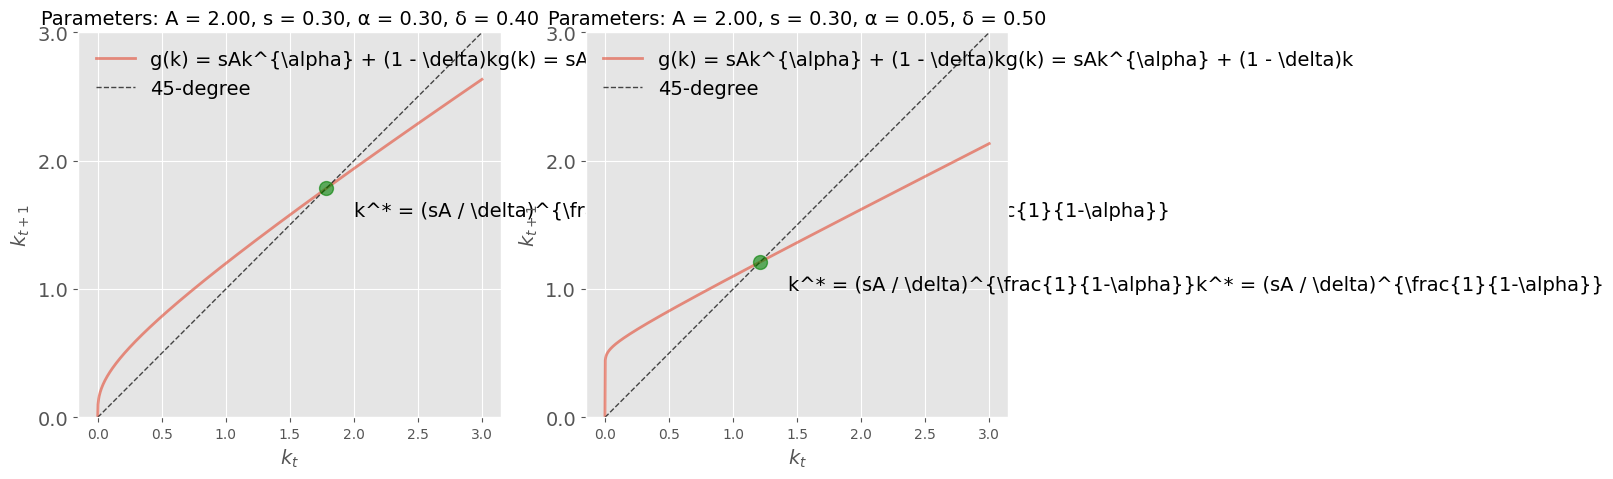

In [4]:
# 绘制两组 Solow 模型参数化（parameterization）下的图形和解析解
params1 = create_solow_params()
params2 = create_solow_params(alpha=0.05, delta=0.5)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plot_45(params1, axs[0])
plot_45(params2, axs[1])
plt.tight_layout()
plt.show()

True Steady State: k* = 1.7847
Newton-Method:
Converged to k = 1.7846
Minimal Functional Value =1.7846
Number of iterations = 60


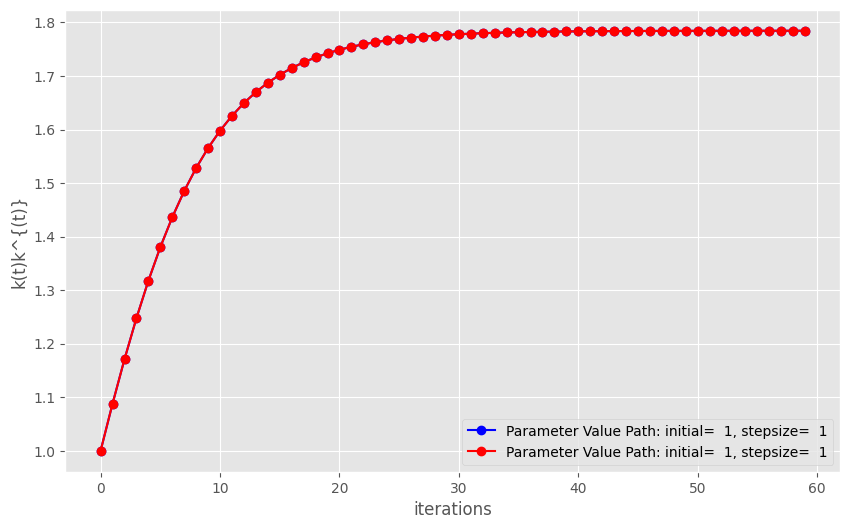

In [7]:
params = create_solow_params()
stepsize = 1.0
# 使用梯度下降法（gradient descent）求解 Solow 模型
## 第 0 步：定义梯度（gradient）和 Hessian 矩阵（Hessian） 
def Gradg(k, params):
    A, s, alpha, delta = params
    return 2*(s*A*k**alpha - delta*k)*(s*A*alpha*k**(alpha-1) - delta) 
## 第 1 步：更新参数（parameters）
## 初始化（initialization） 
k0 = 1 #初始值（initial value） 
tol = 1e-5 #收敛容差（tolerance for convergence） 
##梯度下降法（gradient descent method） 
k = k0 
k_list = [k]
funv_list = [g(k, params)]
while True:
    k_new = k - Gradg(k, params)
    k_list.append(k_new)
    funv_list.append(g(k_new, params))
    if abs(k_new - k) < tol:
        break
    k = k_new

print("True Steady State: k* = {:.4f}".format(exact_fixed_point(params)))
print('Newton-Method:')
print('Converged to k = {:.4f}'.format(k))
print('Minimal Functional Value ={:.4f}'.format(g(k, params)))
print('Number of iterations =', len(funv_list))
#绘制 k 的迭代路径和函数值
plt.plot(k_list, 'o-', color='blue', label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(k0, stepsize))
plt.xlabel('iterations')
plt.ylabel('k(t)k^{(t)}')
#绘制 k 的迭代路径和函数值
plt.plot(k_list, 'o-', color='red', label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(k0, stepsize))
plt.xlabel('iterations')
plt.ylabel('k(t)k^{(t)}')
plt.legend()
plt.show()

## 梯度下降算法（Gradient Descent Algorithms）


**优化问题（Optimization Problem）**：对于 $f: \mathbb{R}^n \rightarrow \mathbb{R}$ $$\min_{\theta} f(\theta)$$
 * $f(\theta)$ 可微（differentiable），例如损失函数（loss function）
 * $\theta$ 是连续变量（continuous）

**梯度下降（Gradient Descent）**：用于寻找目标函数最小值的一阶迭代优化算法（first-order iterative optimization algorithm）。
$$ \theta^{(k+1)} = \theta^{(k)} - \alpha_k \nabla_{\theta} f(\theta^{(k)})$$
  * $\alpha_k$ 是**学习率（learning rate，也称步长 step size）**
  * $\nabla f(\theta)$：目标函数（objective function）的梯度（gradient）
  * 在结构估计（structural estimation）、机器学习（machine learning）和深度学习（deep learning）中，常用于优化损失函数（loss functions）。

**目标（Goal）**：*沿最陡下降方向（steepest descent direction）移动以寻找最小值*

### 梯度下降算法（Gradient Descent Algorithm，续）

**为什么使用梯度下降（Why Gradient Descent）？**：对 $f(\theta)$ 在 $\theta^{(k)}$ 附近作泰勒展开（Taylor expansion）：

$$
\begin{aligned}
f(\theta) ={}& f(\theta^{(k)}) + \nabla_{\theta} f(\theta^{(k)})^T(\theta-\theta^{(k)}) \\
\Rightarrow f(\theta^{(k+1)}) ={}& f(\theta^{(k)}) + \nabla_{\theta} f(\theta^{(k)})^T(\theta^{(k+1)}-\theta^{(k)}) \\
\Rightarrow f(\theta^{(k+1)}) ={}& f(\theta^{(k)}) - \alpha_k\|\nabla_{\theta} f(\theta^{(k)})\|^2 \leq f(\theta^{(k)}).
\end{aligned}
$$

可以证明，当 $\alpha_k=1$ 时，该方向是**最陡下降方向（steepest descent direction）**（[见附录](#convergence-properties-of-gradient-descent-based-method)）。

***
> **算法步骤（Algorithm Steps）**：

> 1. **初始化（Initialization）**：选择 $\theta^{(0)}$ 的初始值。

> 2. **计算梯度（Compute Gradient）**：在当前点 $\theta^{(k)}$ 计算梯度 $\nabla_{\theta} f(\theta^{(k)})$。

> 3. **更新参数（Update Parameters）**：使用梯度和学习率（learning rate）更新参数：
   $$ \theta^{(k+1)} = \theta^{(k)} - \alpha_k \nabla_{\theta} f(\theta^{(k)})$$

> 4. **收敛检查（Convergence Check）**：检查目标函数或参数的变化是否低于某个阈值（threshold），即 $\|\nabla f(x)\|$ 是否足够小。

***

### 扩展 1：随机梯度下降（Stochastic Gradient Descent, SGD）
***

- 对于**大规模数据集（large datasets）**，计算完整梯度 $\nabla f(x)$ 成本很高。

> **更新规则（Updating Rule）**：**SGD** 使用数据的**随机子集（random subset，mini-batch）**近似梯度：$$
  \theta^{(k+1)} = \theta^{(k)} - \alpha_k \nabla f_{i_k}(\theta^{(k)})$$ 其中 $f_{i_k}$ 是随机选取的数据点或批次（batch）上的损失。

- **优点（Pros）**：更新更快，并可能跳出较浅的局部最小值（local minima）。

- **缺点（Cons）**：收敛过程有噪声（noisy convergence），并且需要调节学习率和批量大小（batch size）。


### 🧮 扩展 2：牛顿法（Newton’s Method）
***

- 使用曲率信息（curvature information，二阶导数）以获得更快收敛。

> **牛顿法更新规则（Update Rule for Newton's Method）**：$$
\theta^{(k+1)} = \theta^{(k)} - [\nabla^2 f(\theta^{(k)})]^{-1} \nabla f(\theta^{(k)})$$

- **优点（Pros）**：在最优点附近具有**二次收敛（quadratic convergence）**。
  - **二次收敛（Quadratic convergence）**：近似解中正确数字的数量大致在每次迭代后翻倍。
  - 关于牛顿法（Newton's Method）的收敛性质，见[附录](#Convergence-Properties-of-Newton's-Method)。
  
- **缺点（Cons）**：
  - 计算成本高（需要 Hessian 矩阵的逆，inverse of Hessian）。
  - 不适合高维问题（high-dimensional problems）。

### 扩展 3：约束优化的拉格朗日方法（Lagrangian Methods for Constrained Optimization）
***
**问题表述（Problem Formulation）**：$$ \min f(\theta)  \\ \text{ s.t. } g(\theta) = 0$$

- 通过把约束代入目标函数，这个问题有可能转化为无约束优化问题（unconstrained optimization problem）。
  
- **拉格朗日函数（Lagrangian function）**：$$\mathcal{L}(\theta, \lambda) = f(\theta) + \lambda^T g(\theta)$$

- **求解（Solve）**：寻找鞍点（saddle point）$(\theta ^*, \lambda^*)$，使得：
  $$
  \min_{\theta, \lambda} \mathcal{L}^2(\theta, \lambda) = [f(\theta) + \lambda^T g(\theta)]^2
  $$


### 扩展 4：次梯度方法（Subgradient Methods）
***

- 对于梯度不存在的**非光滑（non-smooth）**函数，在更新规则中使用**次梯度（subgradient）** $g \in \partial f(\theta)$：$$
\theta^{(k+1)} = \theta^{(k)} - \alpha_k g^{(k)}$$
  > **次梯度（Subgradient）**：点 $x_0$ 处的次梯度是任意斜率 $g$，使得对 $f$ 定义域中的所有 $x$ 都有 $$f(x) \geq f(x_0) + g^T (x - x_0)$$。

- 适用于凸但不可微函数（convex, non-differentiable functions），例如 $f(x) = |x|$。
- 与梯度方法（gradient methods）相比，收敛更慢。

### 编程准备：Python 中的循环（Do Loops in Python）
* `while` 循环：只要条件为真，就重复执行一段代码。

* `break`：立即退出循环。
```python
while True:
    if condition:
        break  # 退出循环（break）
    # 代码块（code block）
```
* `for` 循环：遍历一个序列（如列表或 range）。
```python
for i in range(n):
    # 代码块（code block）
```

* `continue`：跳过当前迭代，进入下一次迭代。
```python
for i in range(n):
    if condition:
        continue  # 跳过本次迭代（continue）
    # 代码块（code block）
```
* 循环中的 `else`：循环正常结束后执行；如果被 `break` 中断，则不执行。
```python
for i in range(n):
    if condition:
        break
else:
    # 如果循环没有被 break 中断，则执行这个代码块
```

### 示例：单变量函数的梯度下降与牛顿法（Gradient Descent & Newton's Method）

* **优化问题（Optimization problem）**：$$\min_{\theta}f(\theta) = \theta^3 + \theta^2 + 1$$

* **计算梯度（Compute Gradient）**：$$\nabla f(\theta) = 3\theta^2 + 2\theta$$

* **更新规则（Update Rule）**：$$\theta^{(k+1)} = \theta^{(k)} - \alpha_k (3(\theta^{(k)})^2 + 2\theta^{(k)})$$
  * 对基本梯度下降（basic gradient descent），设 $\alpha_k = 0.1$，并尝试其他取值。
    * **小（Small）**步长可能导致**收敛缓慢（slow convergence）**。
    * **大（Large）**步长可能导致**发散（divergence）**。
  * 对牛顿法（Newton's method），设 $$\alpha_k = \frac{1}{\nabla^2 f(\theta^{(k)})} = 6\theta^{(k)} + 2$$
  * 对两种方法来说，初始值（initial value）的选择都很重要。

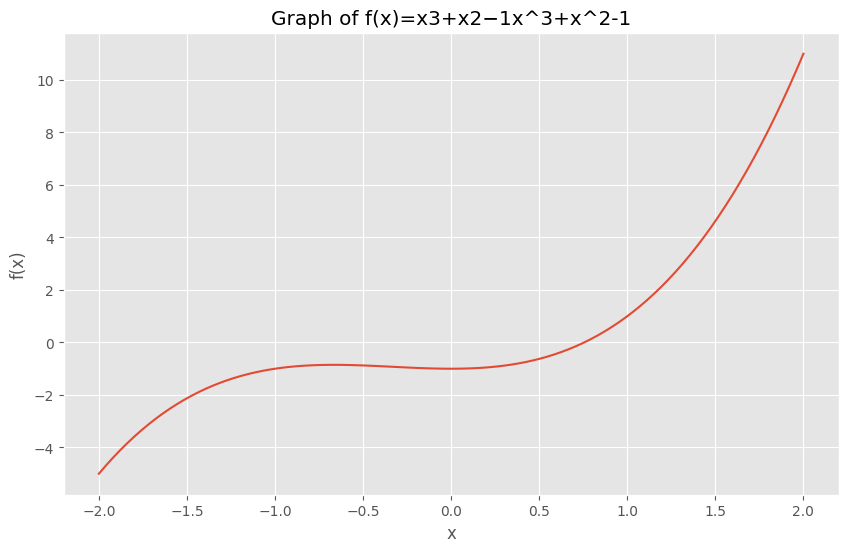

In [5]:
# 用于二次函数优化（quadratic function optimization）的梯度下降 
#函数和导数（derivatives） 
def f(x):
    return x**3 + x**2 - 1
def df(x):
    return 3*x**2 + 2*x
def d2f(x):
    return 6*x + 2
#第 0 步：绘制函数 
x = np.linspace(-2, 2, 100)
y = f(x)
plt.plot(x, y)
plt.title('Graph of f(x)=x3+x2−1x^3+x^2-1')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

Running Time: 0.0001 秒
Converged to x = -1.2722131112823677e-05
Minimal Functional Value = -0.9999999998381495
Number of iterations = 26


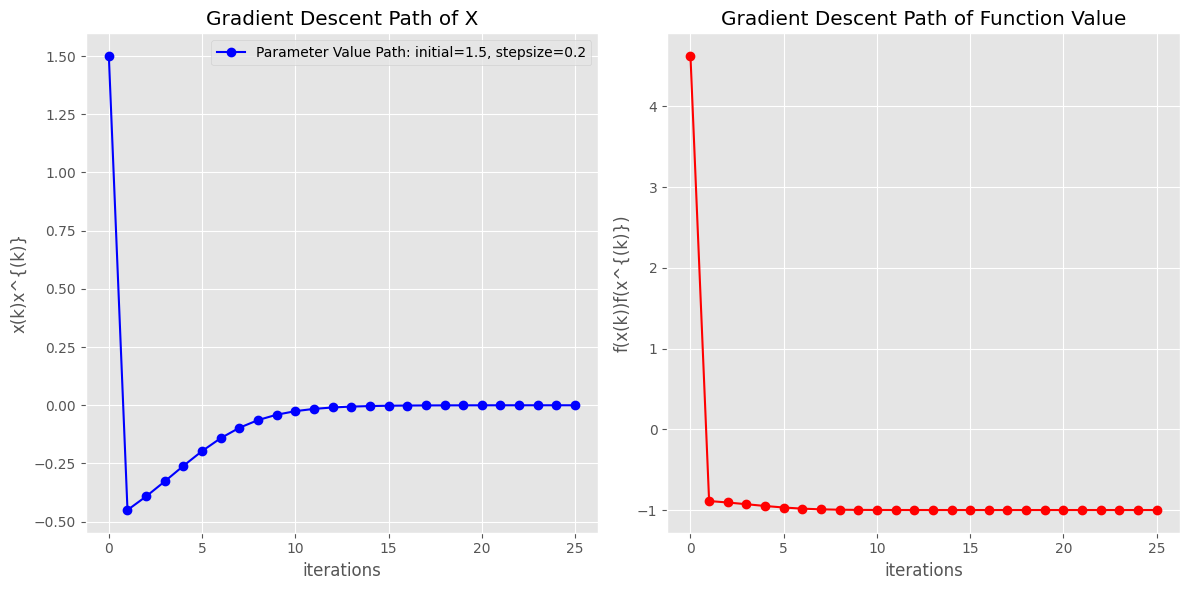

In [6]:
# 固定步长（固定步长（fixed step size））和不同初始点下的梯度下降 
# 实验 1：步长（step size）= 0.2，初始点 1 = 1.5
stepsize = 0.2 #学习率（learning rate） 
x0 = 1.5 #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
#通过迭代求解优化问题（optimization problem）
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#绘制 x 的迭代路径和函数值
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('x(k)x^{(k)}')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('f(x(k))f(x^{(k)})')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

In [7]:
#创建 x 和 f(x) 迭代路径的动画（animation）
fig, ax1 = plt.subplots(1, 1)
x = np.linspace(-1.5, 1.5, 100)
y = f(x)
ax1.plot(x, y)
line1, = ax1.plot([], [], 'o-', color='blue')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)f(x)')
ax1.set_title('Gradient Descent Path of X')
def update(frame):
    line1.set_data(x_list[:frame+1], funv_list[:frame+1])
    return line1,

ani = FuncAnimation(fig, update, frames=len(x_list), interval=300, blit=True)
plt.close(fig)  # 防止静态图重复显示
HTML(ani.to_jshtml())

Converged to x = -1200.4281542541562
Minimal Functional Value = -1728409259.6407516
Number of iterations = 6


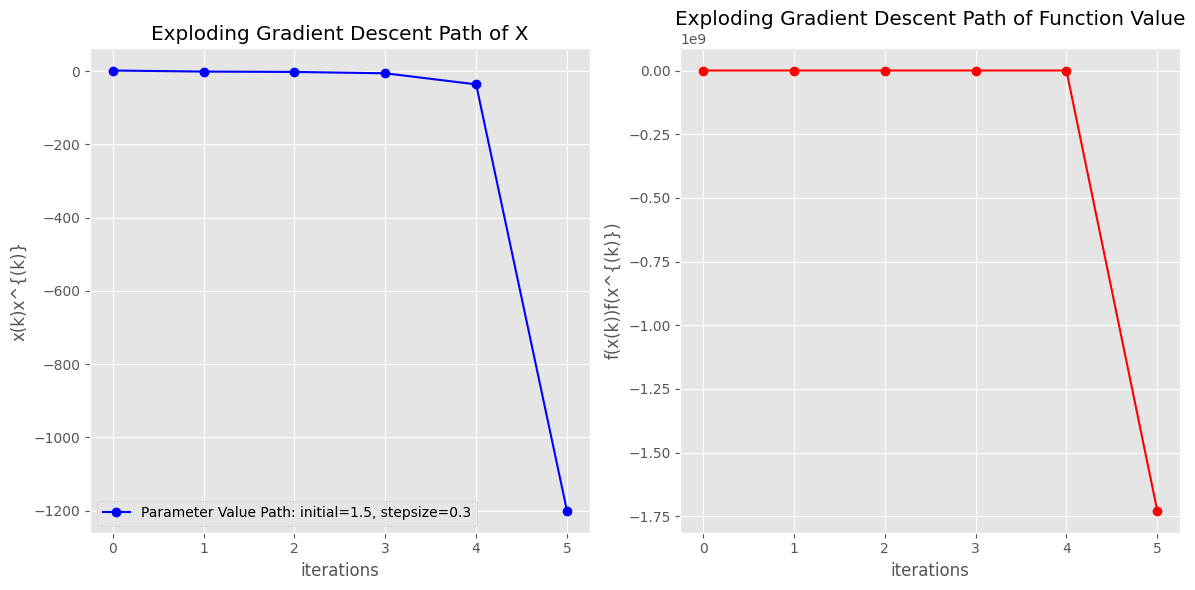

In [8]:
# 实验 2：步长（step size）= 0.3，初始点 1 = 1.5
stepsize = 0.3 #学习率（learning rate） 
x0 = 1.5 #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
#通过迭代求解优化问题（optimization problem）
x = x0
funv_list = [f(x)]
x_list = [x]
Max_iter = 5
for i in range(Max_iter):
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#绘制 x 的迭代路径和函数值
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('x(k)x^{(k)}')
plt.legend()
plt.title('Exploding Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('f(x(k))f(x^{(k)})')
plt.title('Exploding Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0006 秒
Converged to x = 0.0024770958995453335
Minimal Functional Value = -0.9999938487964338
Number of iterations = 1305


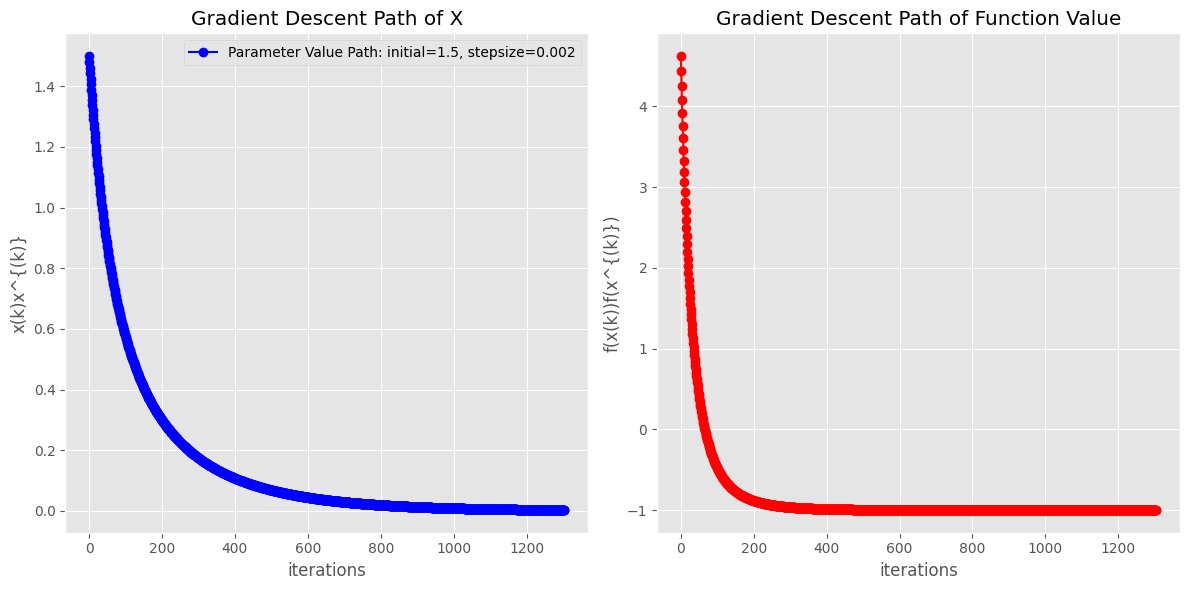

In [9]:
# 实验 4：步长（step size）= 0.001，初始点 = 1.5 
stepsize = 0.002 #学习率（learning rate） 
x0 = 1.5 #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
#通过迭代求解优化问题（optimization problem）
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#绘制 x 的迭代路径和函数值
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('x(k)x^{(k)}')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('f(x(k))f(x^{(k)})')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0001 秒
Converged to x = -6216.948322256572
Minimal Functional Value = -240249177714.18576
Number of iterations = 11


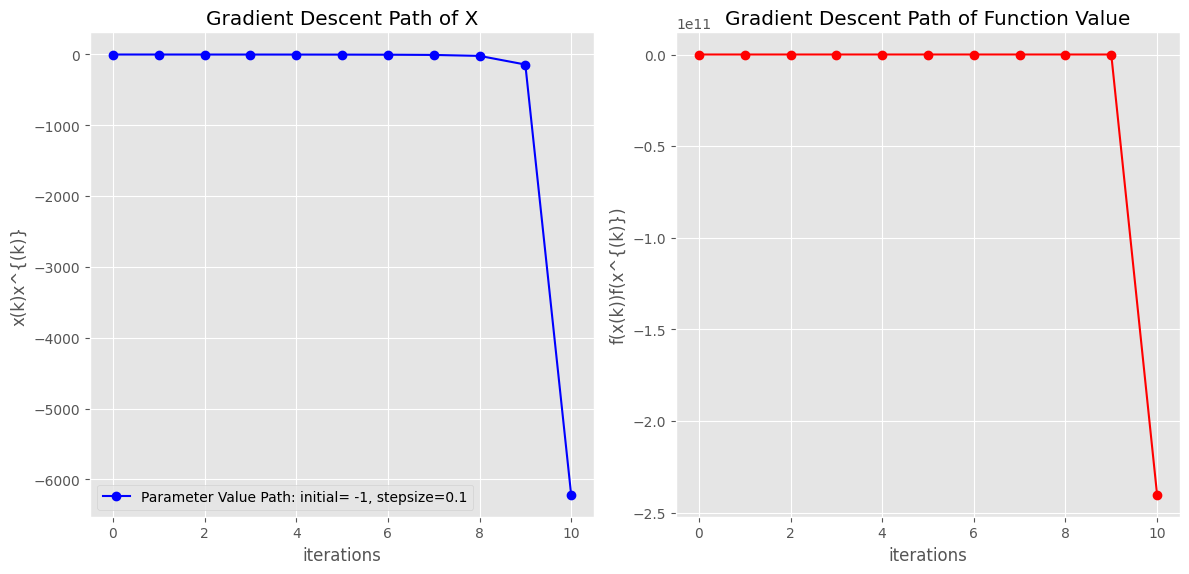

In [10]:
# 实验 5：步长（step size）= 0.1，初始点 = 1.5 
stepsize = 0.1 #学习率（learning rate） 
x0 = -1 #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
#通过迭代求解优化问题（optimization problem）
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
max_iter = 10
for i in range(max_iter):
    x_new = x - stepsize * df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#绘制 x 的迭代路径和函数值
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('x(k)x^{(k)}')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('f(x(k))f(x^{(k)})')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0001 秒
Converged to x = 4.0091730049920005e-11
Minimal Functional Value = -1.0
Number of iterations = 7


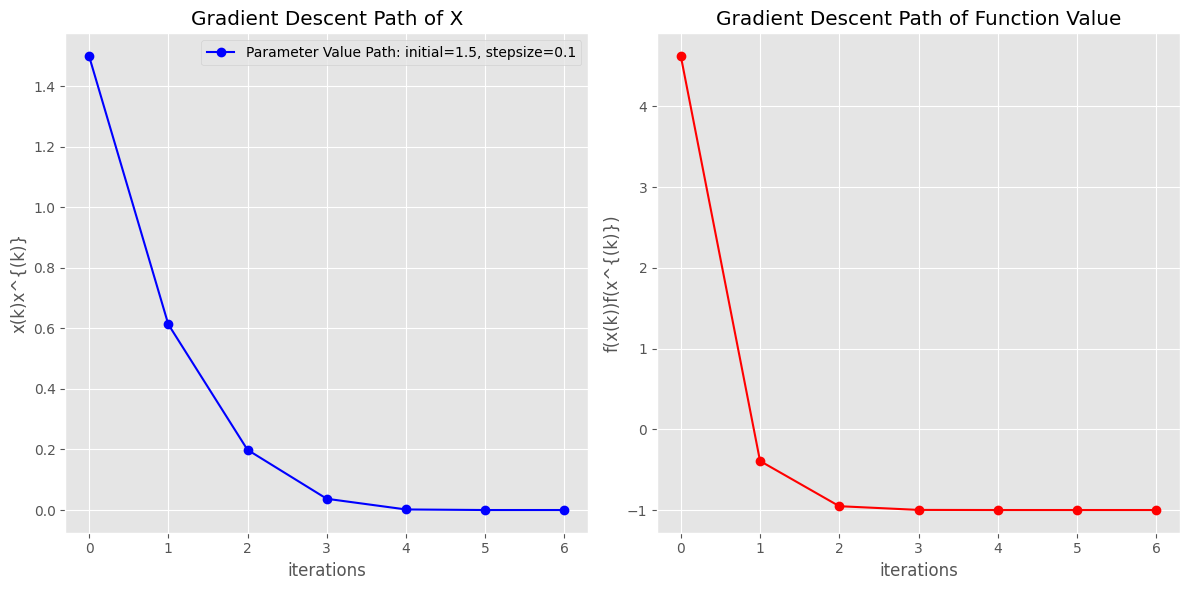

In [11]:
# 实验 6：牛顿法（Newton's method），初始点 = 1.5 
x0 = 1.5 #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
#通过迭代求解优化问题（optimization problem）
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - 1/d2f(x)* df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#绘制 x 的迭代路径和函数值
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('x(k)x^{(k)}')
plt.legend()
plt.title('Gradient Descent Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('f(x(k))f(x^{(k)})')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0001 秒
Converged to x = -0.6666666666666667
Minimal Functional Value = -0.8518518518518519
Number of iterations = 7


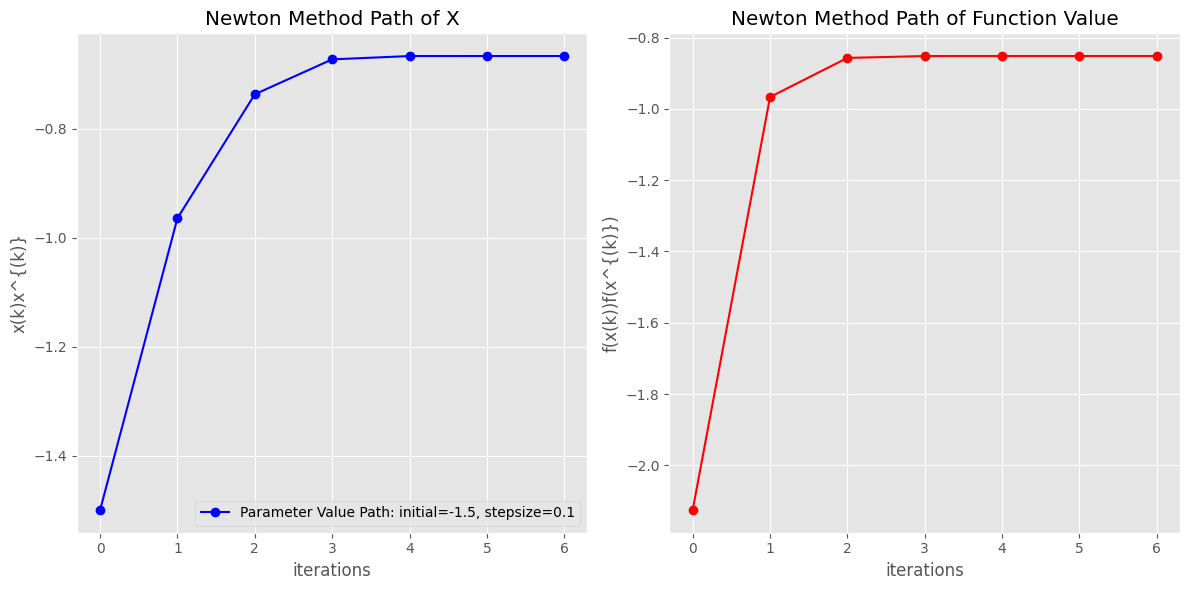

In [12]:
# 实验 7：牛顿法（Newton's method），初始点 = -1.5（停在局部最大值 local maximum） 
x0 = -1.5 #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
#通过迭代求解优化问题（optimization problem）
x = x0
funv_list = [f(x)]
x_list = [x]
start_time = time.time()  # 记录开始时间
while True:
    x_new = x - 1/d2f(x)* df(x)
    x_list.append(x_new)
    funv_list.append(f(x_new))
    if abs(x_new - x) < tol:
        break
    x = x_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to x =', x_new)
print('Minimal Functional Value =', f(x_new))
print('Number of iterations =', len(funv_list))
#绘制 x 的迭代路径和函数值
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x_list, 'o-', color='blue', 
         label='Parameter Value Path: initial={:3g}, stepsize={:3g}'.format(x0, stepsize))  
plt.xlabel('iterations')
plt.ylabel('x(k)x^{(k)}')
plt.legend()
plt.title('Newton Method Path of X')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('f(x(k))f(x^{(k)})')
plt.title('Newton Method Path of Function Value')
plt.tight_layout()
plt.show()

## 示例：线性回归的梯度下降（Gradient Descent for Linear Regression）

- **回归模型（Regression Model）**：$$\large y = b + w x + \epsilon$$

- **优化问题（Optimization Problem）**：最小化**均方误差（mean squared error, MSE）**，即损失函数（loss function）：
$$\large MSE(w, b) = \frac{1}{n} \sum_{i=1}^n [y_i - (b + w x_i)]^2$$

$$
\begin{bmatrix}
b^{(k+1)} \\
w^{(k+1)}
\end{bmatrix}
=
\begin{bmatrix}
b^{(k)} \\
w^{(k)}
\end{bmatrix}
-
\alpha_k
\begin{bmatrix}
\frac{\partial{\text{MSE}(b^{(k)}, w^{(k)})}}{\partial{b}} \\
\frac{\partial{\text{MSE}(b^{(k)}, w^{(k)})}}{\partial{w}}
\end{bmatrix}
$$

### 线性回归的梯度与 Hessian 矩阵（Gradient and Hessian）

- **计算梯度（Compute the Gradients）**：
$$
\begin{aligned}
\frac{\partial{\text{MSE}}}{\partial{b}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{b}} &= \frac{2}{n} \sum_{i=1}^n{(b + w x_i - y_i)} 
\\
\frac{\partial{\text{MSE}}}{\partial{w}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{w}} &= \frac{2}{n} \sum_{i=1}^n{(b + w x_i - y_i) x_i} 
\end{aligned}
$$

- **计算 Hessian 矩阵（Compute the Hessian）**：
$$
\begin{aligned}
 H & = \begin{bmatrix}
\frac{\partial^2{\text{MSE}}}{\partial{b^2}} & \frac{\partial^2{\text{MSE}}}{\partial{b \partial{w}}} \\[5pt]
\frac{\partial^2{\text{MSE}}}{\partial{w \partial{b}}} & \frac{\partial^2{\text{MSE}}}{\partial{w^2}} 
\end{bmatrix} \\
& = \begin{bmatrix}
2 & \frac{2}{n} \sum_{i=1}^n x_i  \\[5pt] 
\frac{2}{n} \sum_{i=1}^n x_i & \frac{2}{n} \sum_{i=1}^nx_i^2
\end{bmatrix} \\
\end{aligned}
  $$
- **更新规则（Update Rule）**：
   - 对原始梯度下降（raw gradient descent），$\alpha_k$ 被设为常数：[Google 学习率练习（Learning Rate Exercise）](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent-exercise)
   - 对牛顿法（Newton's method），$\alpha_k = H^{-1}$

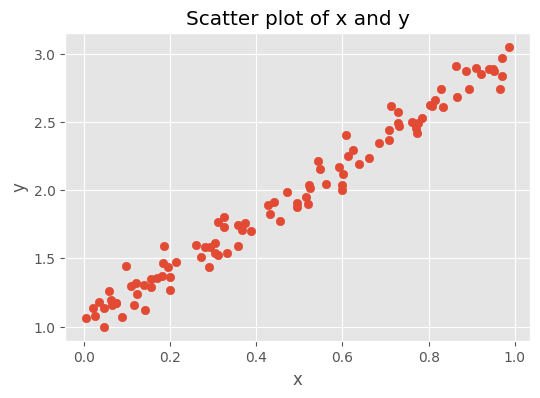

In [13]:
#数据生成过程（data generation process）
true_b = 1
true_w = 2
N = 100 #样本量（sample size） 
# 生成数据（data generation）
np.random.seed(42)
x = np.random.rand(N, 1)
epsilon = (.1 * np.random.randn(N, 1))
y = true_b + true_w * x + epsilon
# 绘制 x 和 y 的散点图（scatter plot） 
plt.figure(figsize=(6, 4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x and y")
plt.show() 

initialized parameter values: [0.49671415] [-0.1382643]


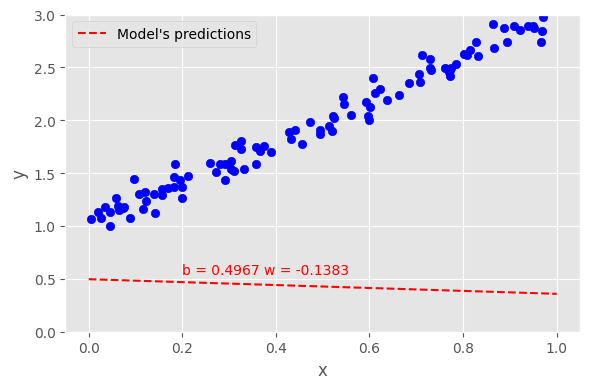

In [14]:
# 使用梯度下降（gradient descent）进行优化
#第 0 步：初始化参数（parameters） 
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)
print('initialized parameter values:', b, w)
#第 1 步：计算并可视化模型预测（model prediction） 
yhat = b + w * x #计算模型预测值（model prediction）
x_range = np.linspace(0, 1, 101) #设置数据范围（data range） 
yhat_range = b + w * x_range #生成预测值（prediction）
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_ylim([0, 3])
ax.scatter(x, y, color='blue') #数据集（dataset） 
ax.plot(x_range, yhat_range, label='Model\'s predictions', c='red', linestyle='--')
ax.annotate('b = {:.4f} w = {:.4f}'.format(b[0], w[0]), xy=(.2, .55), c='red')
ax.legend(loc=0)
fig.tight_layout()

In [15]:
#可视化 MSE（损失函数 loss function）的曲面
#生成 b 和 w 取值的网格（grid）
b_range = np.linspace(true_b - 3, true_b + 3, 101)
w_range = np.linspace(true_w - 3, true_w + 3, 101)
bs, ws = np.meshgrid(b_range, w_range) # meshgrid 是生成 b 和 w 网格的便捷函数
print('shape', bs.shape, ws.shape)
print('---------------------------------------')
print('bs:', bs)
print('---------------------------------------')
print('ws:', ws)

shape (101, 101) (101, 101)
---------------------------------------
bs: [[-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 ...
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]
 [-2.   -1.94 -1.88 ...  3.88  3.94  4.  ]]
---------------------------------------
ws: [[-1.   -1.   -1.   ... -1.   -1.   -1.  ]
 [-0.94 -0.94 -0.94 ... -0.94 -0.94 -0.94]
 [-0.88 -0.88 -0.88 ... -0.88 -0.88 -0.88]
 ...
 [ 4.88  4.88  4.88 ...  4.88  4.88  4.88]
 [ 4.94  4.94  4.94 ...  4.94  4.94  4.94]
 [ 5.    5.    5.   ...  5.    5.    5.  ]]


In [16]:
# 计算每组 b 和 w 对应的 MSE
all_predictions = np.apply_along_axis(
    func1d=lambda x: bs + ws * x, # 对 x 的每一行进行线性预测（linear prediction）
    axis=1, 
    arr=x
)
print("predictions", all_predictions.shape)
all_labels = y.reshape(-1, 1, 1)
print('transformed data shape:', all_labels.shape)
all_errors = (all_predictions - all_labels)
print('errors shape:', all_errors.shape)
all_losses = (all_errors ** 2).mean(axis=0) #对样本取平均
print('losses shape:', all_losses.shape)

predictions (100, 101, 101)
transformed data shape: (100, 1, 1)
errors shape: (100, 101, 101)
losses shape: (101, 101)


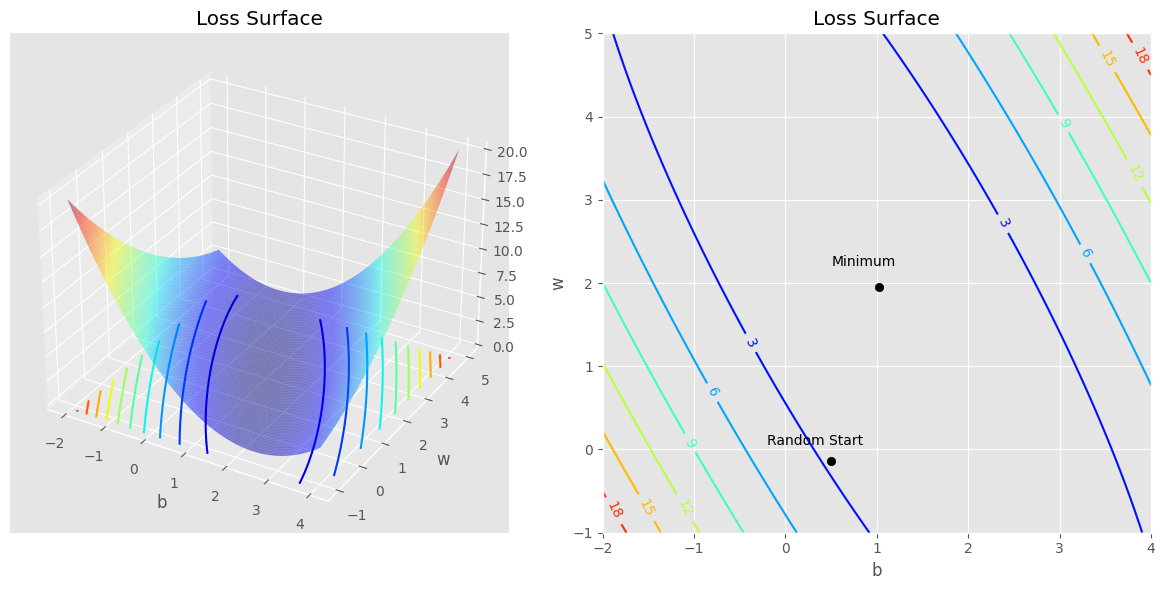

In [17]:
#绘制 b 和 w 的 MSE 曲面 
figure = plt.figure(figsize=(12, 6))
# 第 1 张图
ax1 = figure.add_subplot(1, 2, 1, projection='3d')
ax1.set_xlabel('b')
ax1.set_ylabel('w')
ax1.set_title('Loss Surface')
surf = ax1.plot_surface(bs, ws, all_losses, rstride=1, cstride=1, alpha=.5, cmap=plt.cm.jet, linewidth=0, antialiased=True)
ax1.contour(bs[0, :], ws[:, 0], all_losses, 10, offset=-1, cmap=plt.cm.jet)
ax1.view_init(30, -60)
# 第 2 张图
regression = LinearRegression()
regression.fit(x, y)
b_minimum, w_minimum = regression.intercept_[0], regression.coef_[0][0] #用回归方法得到最小值（minimum）
ax2 = figure.add_subplot(1, 2, 2)
ax2.set_xlabel('b')
ax2.set_ylabel('w')
ax2.set_title('Loss Surface')
CS = ax2.contour(bs[0, :], ws[:, 0], all_losses, cmap=plt.cm.jet)
ax2.clabel(CS, inline=1, fontsize=10)
ax2.scatter(b_minimum, w_minimum, c='k') # 最小值（minimum）
ax2.scatter(b, w, c='k') # 随机初始点（random start）
ax2.annotate('Random Start', xy=(-.2, 0.05), c='k')
ax2.annotate('Minimum', xy=(.5, 2.2), c='k')   
figure.tight_layout()

Running Time: 0.0023 秒
Converged to (b,w) =(1.0216,1.9539)
Minimal Functional Value = 0.008065846759726845
Number of iterations = 130


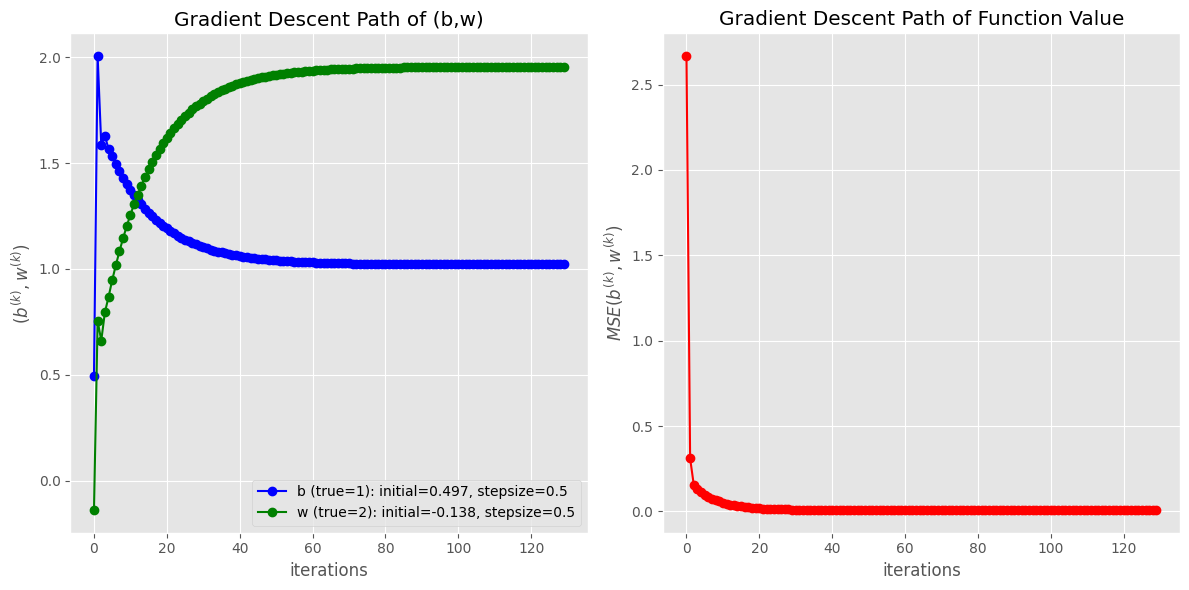

In [18]:
# 实验 1：随机初始点（random start），步长（step size）= 0.2
# 第 2 步：计算梯度（gradient）并可视化 
stepsize = 0.5 #学习率（learning rate） 
b0 = b[0] #初始点 1（initial point 1）
w0 = w[0] #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
def mse_gradient(b, w):
    partial_b = (2 * (b + w * x - y)).mean()
    partial_w = (2 * (b + w * x - y) * x).mean()
    return partial_b, partial_w
partial2_b = 2
partial_bw = (2 * x).mean()
partial2_w = (2 * (x ** 2)).mean()
mse_hessian = np.array([[partial2_b, partial_bw], [partial_bw, partial2_w]])
# 第 3 步：通过迭代求解优化问题（optimization problem）
theta0 = np.array([b0, w0]) #初始点 1（initial point 1）
funv_list = [np.mean((b0 + w0 * x - y) ** 2)]
theta_list = [theta0]
theta = theta0
start_time = time.time()  # 记录开始时间
while True:
    gradient = mse_gradient(theta[0], theta[1])
    theta_new = theta - stepsize * np.array(gradient)
    theta_list.append(theta_new)
    funv_list.append(np.mean((theta_new[0] + theta_new[1] * x - y) ** 2))
    if np.linalg.norm(theta_new - theta) < tol:
        break
    theta = theta_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to (b,w) =({:.4f},{:.4f})'.format(theta_new[0], theta_new[1]))
print('Minimal Functional Value =', funv_list[-1])
print('Number of iterations =', len(funv_list))
#绘制 b、w 和函数值的迭代路径
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot([theta[0] for theta in theta_list], 'o-', color='blue', label='b (true=1): initial={:.3g}, stepsize={:3g}'.format(b0, stepsize))
plt.plot([theta[1] for theta in theta_list], 'o-', color='green', label='w (true=2): initial={:.3g}, stepsize={:3g}'.format(w0, stepsize))
plt.xlabel('iterations')
plt.ylabel('$(b^{(k)},w^{(k)})$')
plt.legend()
plt.title('Gradient Descent Path of (b,w)')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$MSE(b^{(k)},w^{(k)})$')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0036 秒
Converged to (b,w) =(1.0216,1.9539)
Minimal Functional Value = 0.008065846693800503
Number of iterations = 79


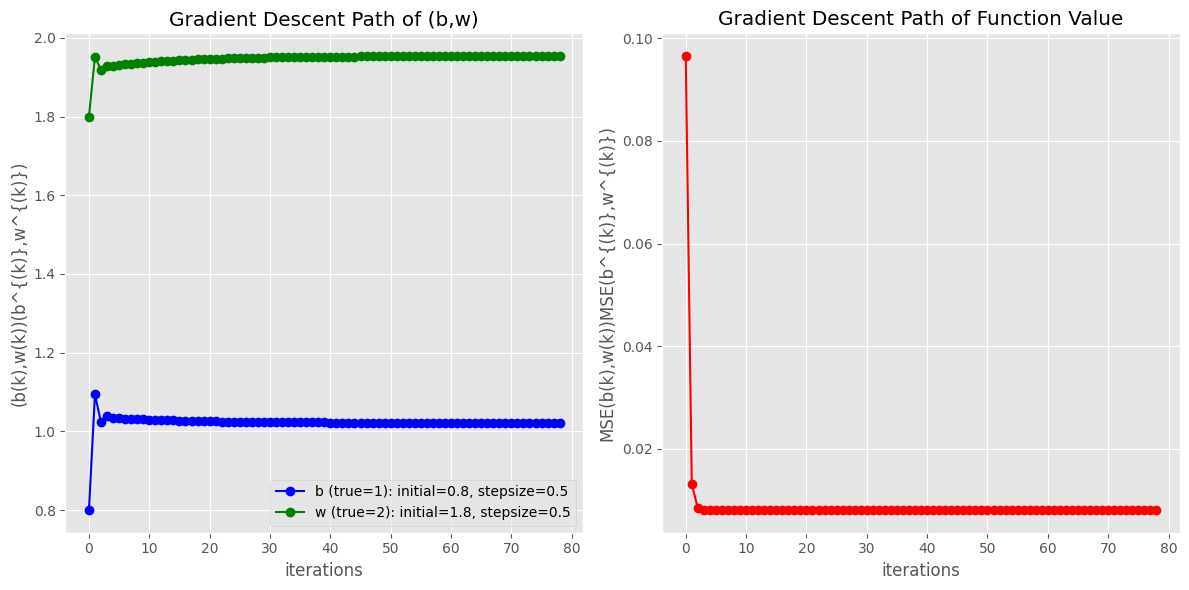

In [19]:
# 实验 3：从最小值邻域（neighborhood of the minimum）开始，步长（step size）= 0.2
# 第 2 步：计算梯度（gradient）并可视化 
b0 = 0.8 #初始点 2（initial point 2）
w0 = 1.8 #初始点 2（initial point 2）
# 第 3 步：通过迭代求解优化问题（optimization problem）
theta0 = np.array([b0, w0]) #初始点 1（initial point 1）
funv_list = [np.mean((b0 + w0 * x - y) ** 2)]
theta_list = [theta0]
theta = theta0
start_time = time.time()  # 记录开始时间
while True:
    gradient = mse_gradient(theta[0], theta[1])
    theta_new = theta - stepsize * np.array(gradient)
    theta_list.append(theta_new)
    funv_list.append(np.mean((theta_new[0] + theta_new[1] * x - y) ** 2))
    if np.linalg.norm(theta_new - theta) < tol:
        break
    theta = theta_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to (b,w) =({:.4f},{:.4f})'.format(theta_new[0], theta_new[1]))
print('Minimal Functional Value =', funv_list[-1])
print('Number of iterations =', len(funv_list))
#绘制 b、w 和函数值的迭代路径
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot([theta[0] for theta in theta_list], 'o-', color='blue', label='b (true=1): initial={:.3g}, stepsize={:3g}'.format(b0, stepsize))
plt.plot([theta[1] for theta in theta_list], 'o-', color='green', label='w (true=2): initial={:.3g}, stepsize={:3g}'.format(w0, stepsize))
plt.xlabel('iterations')
plt.ylabel('(b(k),w(k))(b^{(k)},w^{(k)})')
plt.legend()
plt.title('Gradient Descent Path of (b,w)')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('MSE(b(k),w(k))MSE(b^{(k)},w^{(k)})')
plt.title('Gradient Descent Path of Function Value')
plt.tight_layout()
plt.show()

Running Time: 0.0003 秒
Converged to (b,w) =(1.0215,1.9540)
Minimal Functional Value = 0.008065845639670537
Number of iterations = 3


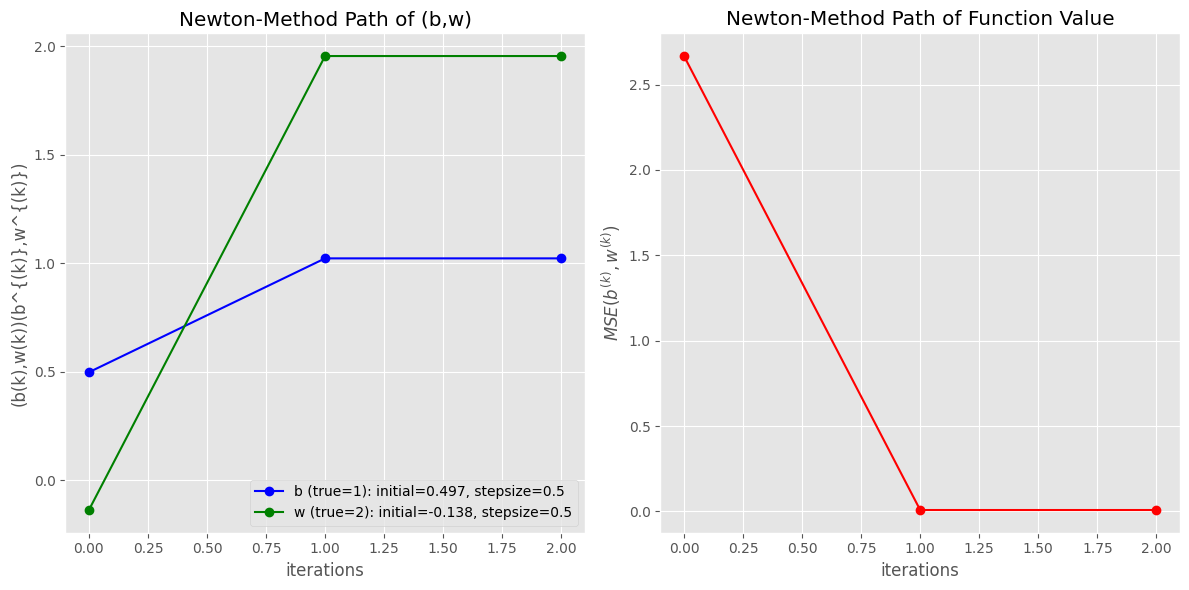

In [20]:
# 实验 3：牛顿法（Newton method），随机初始点，步长（step size）= 0.2
# 第 2 步：计算梯度（gradient）并可视化 
b0 = b[0] #初始点 1（initial point 1）
w0 = w[0] #初始点 1（initial point 1）
tol = 1e-5 #收敛容差（tolerance for convergence）
# 第 3 步：通过迭代求解优化问题（optimization problem）
theta0 = np.array([b0, w0]) #初始点 1（initial point 1）
funv_list = [np.mean((b0 + w0 * x - y) ** 2)]
theta_list = [theta0]
theta = theta0
start_time = time.time()  # 记录开始时间
while True:
    gradient = mse_gradient(theta[0], theta[1])
    theta_new = theta -  np.linalg.inv(mse_hessian) @ gradient #牛顿法（Newton method）更新 
    theta_list.append(theta_new)
    funv_list.append(np.mean((theta_new[0] + theta_new[1] * x - y) ** 2))
    if np.linalg.norm(theta_new - theta) < tol:
        break
    theta = theta_new
end_time = time.time()  # 记录结束时间
print("Running Time: {:.4f} 秒".format(end_time - start_time))
print('Converged to (b,w) =({:.4f},{:.4f})'.format(theta_new[0], theta_new[1]))
print('Minimal Functional Value =', funv_list[-1])
print('Number of iterations =', len(funv_list))
#绘制 b、w 和函数值的迭代路径
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot([theta[0] for theta in theta_list], 'o-', color='blue', label='b (true=1): initial={:.3g}, stepsize={:3g}'.format(b0, stepsize))
plt.plot([theta[1] for theta in theta_list], 'o-', color='green', label='w (true=2): initial={:.3g}, stepsize={:3g}'.format(w0, stepsize))
plt.xlabel('iterations')
plt.ylabel('(b(k),w(k))(b^{(k)},w^{(k)})')
plt.legend()
plt.title('Newton-Method Path of (b,w)')
plt.subplot(1, 2, 2)
plt.plot(funv_list, 'o-', color='red')
plt.xlabel('iterations')
plt.ylabel('$MSE(b^{(k)},w^{(k)})$')
plt.title('Newton-Method Path of Function Value')
plt.tight_layout()
plt.show()

## Python 中的优化：`Scipy.optimize`

参考资料（Reference）：[[Scipy Documentation]](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) [[Scipy Tutorial]](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg)

* `scipy.optimize.minimize` 是 Python 中一个强大的优化函数。它提供多种用于最小化函数的算法，包括牛顿法（Newton's method）以及许多其他算法。

In [21]:
# 使用 Scipy.optimize 求解回归问题 
from scipy.optimize import minimize
def mse_loss(theta):
    b, w = theta
    return np.mean((b + w * x - y) ** 2)
def mse_gradient_fun(theta):
    b, w = theta
    partial_b = (2 * (b + w * x - y)).mean()
    partial_w = (2 * (b + w * x - y) * x).mean()
    return np.array([partial_b, partial_w])
def mse_hessian_fun(theta):
    return mse_hessian
# 第 1 步：初始猜测值（initial guess）
theta0 = np.array([b0, w0]) #初始点 1（initial point 1）
# 第 2 步：调用使用牛顿法（Newton's method）的优化器（optimizer）
result = minimize(mse_loss, theta0, method='Newton-CG', jac=mse_gradient_fun, hess = mse_hessian_fun, options={'xtol': 1e-5, 'disp': True})
print('Converged to (b,w) =({:.4f},{:.4f})'.format(result.x[0], result.x[1]))
print('Regression Coefficients (b,w) =({:.4f},{:.4f})'.format(b_minimum, w_minimum))

Optimization terminated successfully.
         Current function value: 0.008066
         Iterations: 3
         Function evaluations: 3
         Gradient evaluations: 3
         Hessian evaluations: 3
Converged to (b,w) =(1.0215,1.9540)
Regression Coefficients (b,w) =(1.0215,1.9540)


### 数值微分与数值积分（Numerical Differentiation and Integration）

* **前向差分（forward difference）**：

$$
f'(x_j) \approx \frac{f(x_{j+1}) - f(x_j)}{x_{j+1}-x_j}.
$$

* **后向差分（backward difference）**：

$$
f'(x_j) \approx \frac{f(x_j) - f(x_{j-1})}{x_j - x_{j-1}}.
$$

* **中心差分（central difference）**：

$$
f'(x_j) \approx \frac{f(x_{j+1}) - f(x_{j-1})}{x_{j+1} - x_{j-1}}.
$$

*图：有限差分（finite difference）示意图。*

### 泰勒级数展开与有限差分近似（Taylor Series Expansion and Finite Difference Approximation）

对可微函数（differentiable function）$f(x)$，在点 $x_j$ 附近的泰勒级数展开（Taylor series expansion）为

$$
f(x) = f(x_j) + f'(x_j)(x-x_j) + \frac{f''(x_j)}{2!}(x-x_j)^2 + \frac{f'''(x_j)}{3!}(x-x_j)^3 + \cdots.
$$

对等距点（evenly spaced points）$x_{j+1}=x_j+h$，令 $x=x_{j+1}$，得到

$$
\begin{aligned}
f(x_{j+1}) ={}& f(x_j)+f'(x_j)h+\frac{1}{2}f''(x_j)h^2+\cdots, \\
f'(x_j) ={}& \frac{f(x_{j+1})-f(x_j)}{h}+O(h).
\end{aligned}
$$

因此前向差分近似的误差阶是 $O(h)$。若 $q<p$，$O(h^p)$ 近似会比 $O(h^q)$ 近似更快接近真实值。

类似地，后向差分公式为

$$
f'(x_j)=\frac{f(x_j)-f(x_{j-1})}{h}+O(h).
$$

同时使用 $x_{j+1}$ 和 $x_{j-1}$ 可得到中心差分公式：

$$
\begin{aligned}
f(x_{j+1}) &= f(x_j)+f'(x_j)h+\frac{1}{2}f''(x_j)h^2+\frac{1}{6}f'''(x_j)h^3+\cdots, \\
f(x_{j-1}) &= f(x_j)-f'(x_j)h+\frac{1}{2}f''(x_j)h^2-\frac{1}{6}f'''(x_j)h^3+\cdots, \\
f'(x_j) &= \frac{f(x_{j+1})-f(x_{j-1})}{2h}+O(h^2).
\end{aligned}
$$

中心差分公式（central difference formula）是 $O(h^2)$，但与前向差分和后向差分需要相同量级的计算。

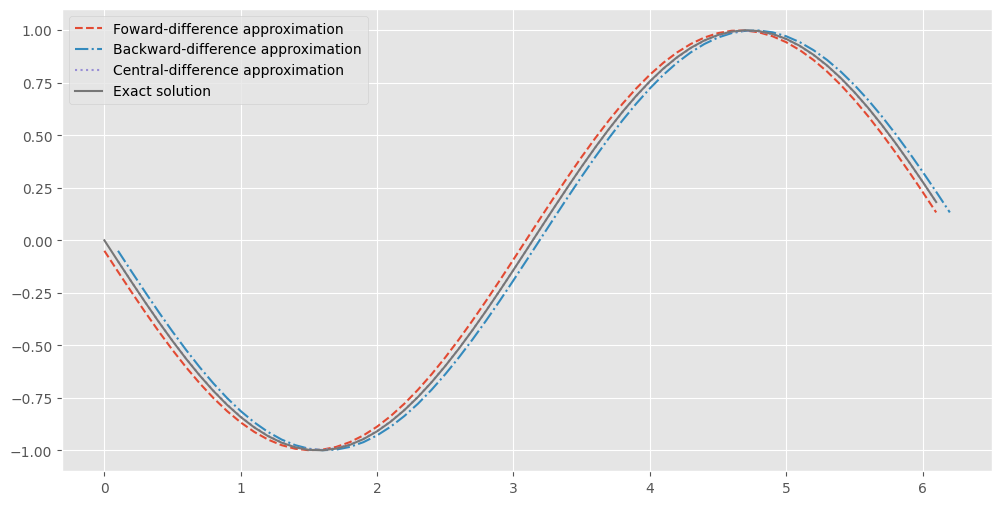

Maximum Error: ForwardDiff=0.0500, BackwardDiff=0.0500, CentralDiff=0.0017


In [22]:
# 示例：数值微分（numerical differentiation） 
h = 0.1 # 步长（step size）
x = np.arange(0, 2*np.pi, h) # 定义网格（grid）
y = np.cos(x)  # 计算函数值
forward_diff = np.diff(y)/h # 计算前向差分（forward difference）向量
backward_diff = (y[1:]-y[:-1])/h # 计算后向差分（backward difference）向量
central_diff = (y[2:]-y[:-2])/(2*h) # 计算中心差分（central difference）向量
x_fdiff = x[:-1] # 计算对应网格（grid）
x_bdiff = x[1:] # 计算对应网格（grid）
x_cdiff = x[1:-1] # 计算对应网格（grid）
exact_solution = -np.sin(x_fdiff) # 计算精确解（exact solution）
# 绘图比较不同解
plt.figure(figsize = (12, 6))
plt.plot(x_fdiff, forward_diff, '--', label = 'Foward-difference approximation')
plt.plot(x_bdiff, backward_diff, '-.',label = 'Backward-difference approximation')
plt.plot(x_cdiff, central_diff, ':', label = 'Central-difference approximation')
plt.plot(x_fdiff, exact_solution, label = 'Exact solution')
plt.legend()
plt.show()
# 计算最大误差（maximum errors） 
print('Maximum Error: ForwardDiff={:.4f}, BackwardDiff={:.4f}, CentralDiff={:.4f}'.format(
    np.max(np.abs(forward_diff - exact_solution)), 
    np.max(np.abs(backward_diff - exact_solution)), 
    np.max(np.abs(central_diff - exact_solution[1:]))))

我们可以用不同的 $h$ 计算数值导数（numerical derivative），并绘制最大误差，以展示不同方法的**精度（accuracy）**。

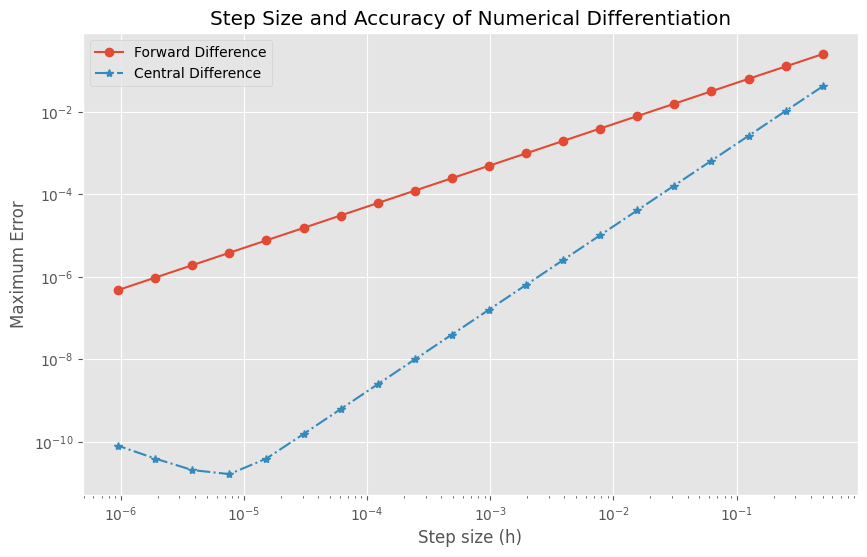

In [23]:
# 比较不同方法的精度（accuracy） 
h = 1
iterations = 20 
step_size = [] 
# 用于存储每个步长最大误差的列表
max_error = [] 
for i in range(iterations):
    h /= 2 
    step_size.append(h) 
    x = np.arange(0, 2 * np.pi, h) 
    y = np.cos(x) 
    forward_diff = np.diff(y)/h # 计算前向差分（forward difference）向量
    central_diff = (y[2:]-y[:-2])/(2*h) # 计算中心差分（central difference）向量
    x_fdiff = x[:-1] # 计算对应网格（grid）
    x_cdiff = x[1:-1] # 计算对应网格（grid）
    exact_solution = -np.sin(x_fdiff)  # 计算精确解（exact solution）
    max_error.append([max(abs(exact_solution - forward_diff)), max(abs(exact_solution[1:] - central_diff))])
# 绘制最大误差与步长的双对数图（log-log plot）
plt.figure(figsize = (10, 6))
plt.loglog(step_size, [r[0] for r in max_error], 'o-', label='Forward Difference') 
plt.loglog(step_size, [r[1] for r in max_error], '*-.', label='Central Difference')  
plt.xlabel('Step size (h)')
plt.ylabel('Maximum Error')
plt.legend()
plt.title('Step Size and Accuracy of Numerical Differentiation')
plt.show()

### Python 中的数值微分：`Autograd`

[`Autograd`](https://github.com/HIPS/autograd/tree/master) 是一个 Python 库，可以对原生 Python 和 NumPy 函数进行自动微分（automatic differentiation）。当机器学习和优化任务需要梯度时，它尤其有用。

* 它在训练机器学习模型时会更常用，但我们也可以把它用于数值微分（numerical differentiation）。

* **安装（Installation）**：`pip install autograd`

C:\Users\Don\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


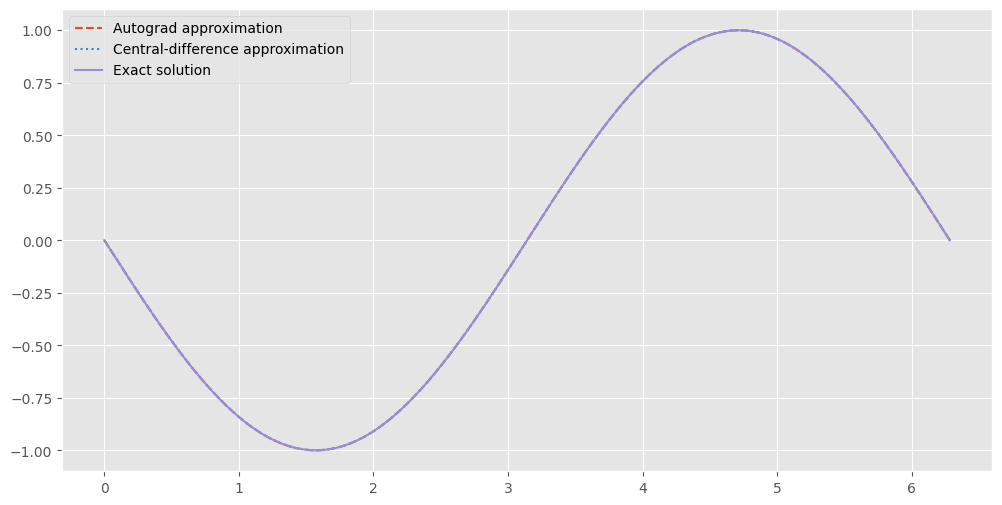

Maximum Error: AutoDiff=0.00000, CentralDiff=0.00000


In [24]:
import autograd.numpy as au
from autograd import elementwise_grad

def f(x): # 目标函数（objective function）
    return au.cos(x) 
grad_f = elementwise_grad(f) # 逐元素导数（elementwise derivative）
# 绘图比较不同解
plt.figure(figsize = (12, 6))
plt.plot(x_cdiff, grad_f(x_cdiff), '--', label = 'Autograd approximation')
plt.plot(x_cdiff, central_diff, ':', label = 'Central-difference approximation')
plt.plot(x_cdiff, exact_solution[1:], label = 'Exact solution')
plt.legend()
plt.show()
# 计算最大误差（maximum errors） 
print('Maximum Error: AutoDiff={:.5f}, CentralDiff={:.5f}'.format(
    np.max(np.abs(grad_f(x_cdiff) - exact_solution[1:])), 
    np.max(np.abs(central_diff - exact_solution[1:]))))

### 数值积分（Numerical Integration）
***

* **黎曼积分（Riemann Integral）**：令 $h = \frac{b-a}{n}$ 表示每个子区间的宽度：$$ \int_a^b f(x) dx = \sum_{i = 0}^{n-1} hf(x_i)+O(h) \text{ (Left end point)}$$ $$\int_a^b f(x) dx = \sum_{i = 1}^{n} hf(x_i)+O(h) \text{ (Right end point)}$$ $$\int_a^b f(x)dx = \sum_{i = 0}^{n-1} hf(\frac{x_{i+1} + x_i}{2})+O(h^3)  \text{ (Midpoint rule)}$$


* 由于中点法（Midpoint Rule）与黎曼积分（Riemann Integral）需要相同次数的计算，我们几乎可以“免费”多获得一阶精度！

### 梯形法则（Trapezoidal Rule）

* **梯形法则（trapezoidal rule）**：使用梯形近似曲线下方的面积。
$$
\int_a^b f(x) dx = \frac{h}{2} \left[f(a) + 2\sum_{i=1}^{n-1} f(x_i) + f(b)\right] + O(h^2)
$$

*图：梯形法则（trapezoidal rule）示意图。*

### Simpson 法则（Simpson's Rule）

* **Simpson 法则（Simpson's rule）**：一种更精确的方法，使用抛物线段（parabolic segments）近似曲线下方的面积。
$$
\int_a^b f(x) dx = \sum_{i=1}^{n-1} \frac{h}{3}[f(x_{i-1})+4f(x_i)+f(x_{i+1})] + O(h^4)$$
*图：Simpson 法则（Simpson's rule）示意图。*

In [25]:
#不同积分方法（integration methods）：以 [0, pi] 上的 f(x)=sin(x) 为例
a = 0
b = np.pi
n = 11
h = (b - a) / (n - 1)
x = np.linspace(a, b, n)
f = np.sin(x)
# 起点（start point）
I_riemannL = h * sum(f[:-1])
err_riemannL = 2 - I_riemannL
# 终点（end point）
I_riemannR = h * sum(f[1::])
err_riemannR = 2 - I_riemannR
# 中点（midpoint） 
I_mid = h * sum(np.sin((x[:-1] + x[1:])/2))
err_mid = 2 - I_mid
# 梯形法则（trapezoidal rule）
I_trap = (h/2)*(f[0] + 2 * sum(f[1:n-1]) + f[n-1])
err_trap = 2 - I_trap
# Simpson 法则（Simpson's rule）
I_simp = (h/3) * (f[0] + 2*sum(f[:n-2:2]) + 4*sum(f[1:n-1:2]) + f[n-1])
err_simp = 2 - I_simp
print('Start_point, End_point, Mid_point, Trape, Simpson \n ({:.4f}, {:.4f}, {:.4f}, {:.4f}, {:.4f})'.format(I_riemannL, I_riemannR, I_mid, I_trap, I_simp))
print("Start_Error, End_Error, Mid_Error, Trape_Error, Simpson_Error \n ({:.4f}, {:.4f}, {:.4f}, {:4f}, {:4f})".format(err_riemannL, err_riemannR, err_mid, err_trap, err_simp))

Start_point, End_point, Mid_point, Trape, Simpson 
 (1.9835, 1.9835, 2.0082, 1.9835, 2.0001)
Start_Error, End_Error, Mid_Error, Trape_Error, Simpson_Error 
 (0.0165, 0.0165, -0.0082, 0.016476, -0.000110)


### 经济学应用 II：需求估计的 BLP 方法（BLP Method for Demand Estimation）
***

* 需求估计方法（demand estimation method）（Berry, Levisohn, and Pakes, 1995）是一种用于估计差异化产品市场（differentiated products markets）需求的模型方法。更多细节可见我之前的 [BLP 讲义](https://gitee.com/zhiyuanryanchen/econ-research-methods/tree/master/2020Fall/Lecture7/13-BLP)。

* [`PyBLP`](https://pyblp.readthedocs.io/en/stable/introduction.html) 是一个用于实现 BLP 方法的 Python 包。建议大家了解一下！

* 在估计过程中，我们需要使用数值积分（numerical integration）来计算市场份额（market shares）：$$ s_{jt} = \int_{A_{jt}} dP_\varepsilon(\varepsilon) dP_\nu(\nu) dP_D(D) \tag{3}$$
  * 其中 $ A_{jt}(x_{\cdot t}, p_{\cdot t}, \delta_{\cdot t}; \theta_2) = \left\{(D_i, \nu_i, \varepsilon_{i, \cdot, t}) : \forall \ell \in J, u_{ijt}\geq u_{i \ell t} \right\} $ 表示消费者集合（set of consumers）。

## 原始定点迭代（Raw Fixed-Point-Based Iterations）
***

### 不动点（Fixed Points）

> **不动点（Fixed Point）**：若点 $ x^* \in X $ 对函数 $ T: X \to X $ 满足：$$\Large T(x^*) = x^*$$ 则称 $x^*$ 是该函数的一个*不动点（fixed point）*。

- **直觉（Intuition）**：对这个值应用函数 $T$ 后，数值不会改变。

- **例子（Examples）**：
  - $ T(x) = \cos(x) $ 在 $ x = 0.739 $ 附近有一个不动点。
  - 在经济学中：最优反应函数（best response function）的**不动点（fixed point）**对应一个**纳什均衡（Nash equilibrium）**。


### 压缩映射（Contraction Mapping）

> **定义（Definition）**：如果函数 $ T: X \to X $ 在**度量空间（metric space）** $ (X, d) $ 上满足：$$\large
  d(T(x), T(y)) \leq \beta \cdot d(x, y), \quad \text{for all } x, y \in X, \text{ with } 0 < \beta < 1$$
则称 $T$ 是一个*压缩映射（contraction）*。


- 常数 $\beta$ 称为 **Lipschitz 常数（Lipschitz constant）**。

- **关键性质（Key Property）**：压缩映射会“缩短”点之间的距离。


- **例子（Examples）**：
  - $T(x) = 0.5x \text{ on } \mathbb{R}$ 是一个压缩映射，其压缩常数（contraction constant）为 $ \beta = 0.5 $。
  
  - $T(x) = x^{0.2}$ 在 $[0, 1]$ 上对某个压缩常数也是压缩映射。

### Banach 不动点定理（Banach Fixed Point Theorem）
***

> **Banach 不动点定理（Banach Fixed Point Theorem）**：如果 $ T $ 是完备度量空间（complete metric space）$ X $ 上的压缩映射（contraction），则：
>    1. 存在一个**唯一不动点（unique fixed point）** $ x^* \in X $。
>    2. 对任意初始点 $ x_0 \in X $，**迭代方法（iterative method）** $ x_{n+1} = T(x_n) $ 都会**收敛（converge）**到 $ x^* $。

- **直觉（Intuition）**：**压缩映射（contraction mapping）**会把所有点“拉”得更近。也就是说，如果两个点相距很远，应用该函数会让它们更接近，而且接近的幅度被一个**压缩因子（contraction factor）**统一约束。

- **收敛速度（Convergence Rate）**：以 $ \beta $ 为速率的线性收敛（linear convergence）。
  
- **缓解维度灾难（curse of dimensionality）**，因为基于矩阵的运算很快！

### 压缩的基于导数的条件（Derivative-Based Condition for Contraction）
***

> **雅可比范数条件（Jacobian Norm Condition）**：设 $T: \mathbb{R}^n \to \mathbb{R}^n$ 是连续可微函数（continuously differentiable function）。如果 $T$ 的 **Lipschitz 常数（Lipschitz constant）**小于 1，即对所有 $x \in \mathbb{R}^n$ 都有 $$ \|\nabla T(x)\| < 1$$，其中 $\|\cdot \|$ 是**算子范数（operator norm）**，则 $T$ 是压缩映射（contraction mapping）。

> **算子范数（Operator Norm）**：对线性算子（linear operator）$A\in \mathbb{R}^{n\times n}$，并令 $\|\cdot\|$ 为 $\mathbb{R}^n$ 上的一个范数。由该范数诱导的算子范数定义为：$$ \|A\|  = \sup_{\|x\|=1} \|Ax\|$$

* 它度量了算子 $A$ 把单位向量最多能“放大”多少。

* 为了确保压缩映射（contraction mapping），我们需要算子范数小于 1。

#### 算子范数示例（Examples of Operator Norms）
***


* **示例 1（Example 1）**：对 $A = \alpha \in \mathbb{R}$，算子范数为 $\|A\| = |\alpha|$。
  
* **示例 2（Example 2）**：对

$$
A=\begin{bmatrix}2&0\\0&0.5\end{bmatrix},
$$

算子范数为 $\|A\|=\max\{2,0.5\}=2$（$\ell_2$ 范数，即欧几里得范数）。
$$\sup_{x_1^2+x_2^2=1} \sqrt{(2x_1)^2 + (0.5x_2)^2} $$

* **示例 3（Example 3）**：对

$$
A=\begin{bmatrix}1&2\\0&1\end{bmatrix}.
$$
  
  * 算子范数为 $\|A\| _{\infty} = \max \{1+2, 0+1\} = 3$（$\ell_{\infty}$ 范数（$\ell_{\infty}$-norm，无穷范数），最大行和）。
  
  * 算子范数为 $\|A\| _{1} = \max \{1+0, 2+1\} = 3$（$\ell_{1}$ 范数（$\ell_{1}$-norm，1 范数），最大列和）。
  
  * 算子范数为 $\|A\| _{2} \approx 2.618$（$\ell_{2}$ 范数（$\ell_{2}$-norm，2 范数））。

### 定点迭代算法（Fixed-Point Iteration Algorithm）
***
- **初始化（Initialization）**：选择 $ x_0 \in X $。
- **迭代（Iteration）**：使用如下规则更新：
  $
  x_{n+1} = T(x_n)
  $

- **停止准则（Stopping Criterion）**：当满足以下条件时停止：
  $
  \|x_{n+1} - x_n\| < \epsilon
  $

- **Python 伪代码（Pseudocode in Python）**：
```python
x = x0
for i in range(max_iter):
    x_new = T(x)
    if norm(x_new - x) < tol:
        break
    x = x_new
```

### 回到应用 I：Solow 增长模型（Revisit Application I: the Solow Growth Model）
***
#### 直接迭代的收敛性（Convergence of Direct Iteration）
- 使用[**单调收敛定理（monotone convergence theorem）**](https://en.wikipedia.org/wiki/Monotone_convergence_theorem)，我们可以证明序列 $\{k_t\}_{t=0}^{\infty}$ 收敛到 $k^*$。

- 此外，如果导数 $g'(k)$ 对所有 $k > 0$ 都满足 $\|g'(k)\| < 1$，则 $g(k) = sAk^\alpha + (1-\delta)k$ 是压缩映射（contraction mapping）；该条件在稳态 $k^*$ 附近成立。

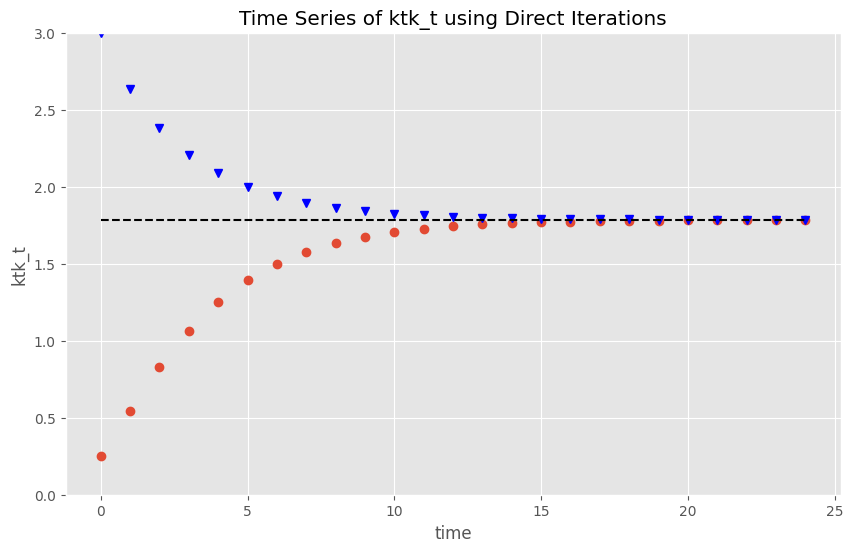

In [26]:
#使用直接迭代（direct iteration）求解稳态（steady state）
def compute_iterates(k_0, f, params, n=25):
    "计算由任意函数 f 生成、长度为 n 的时间序列（time series）。"
    k = k_0
    k_iterates = []
    for t in range(n):
        k_iterates.append(k)
        k = f(k, params)
    return k_iterates
params = create_solow_params()
k_0 = 0.25
k_series = compute_iterates(k_0, g, params)
k_0 = 3.0
k_series1 = compute_iterates(k_0, g, params)
k_star = exact_fixed_point(params)
fig, ax = plt.subplots()
ax.plot(k_series, 'o')
ax.plot(k_series1, 'v', color='blue')
ax.plot([k_star] * len(k_series), 'k--')
ax.set_xlabel("time")
ax.set_ylabel("ktk_t")
ax.set_title("Time Series of ktk_t using Direct Iterations")
ax.set_ylim(0, 3)
plt.show()

### 应用 III：BLP 需求估计中的市场份额迭代（Market Share Iteration in BLP Demand Estimation）

* 在随机系数需求模型（random coefficient demand model）中，市场份额方程（market share equation）为：

$$
s(x,p,\delta,P_{ns};\theta_2)
=\sum_{i=1}^S w_i
\frac{\exp\{\delta_{jt}+[-p_{jt},x_{jt}](\Pi D_i+\Sigma v_i)\}}
{1+\sum_{\ell\in J_t}\exp\{\delta_{\ell t}+[-p_{\ell t},x_{\ell t}](\Pi D_i+\Sigma v_i)\}}.
$$

* 我们需要找到平均效用（mean utility）$\delta$，以求解非线性方程（nonlinear equation）：

$$
s(x,p,\delta;\theta_2)-S=0.
$$

* BLP 证明这是一个压缩映射（contraction mapping），因此可以使用定点迭代（fixed-point iteration）寻找解：

$$
\delta_{\cdot t}^{h+1}
=\delta_{\cdot t}^{h}+\log S_{\cdot t}
-\log s_{\cdot t}(x_{\cdot t},p_{\cdot t},\delta_{\cdot t}^{h};\theta_2).
$$

### 应用 IV：引力模型估计（Gravity Model Estimation）

* 经典的约化式引力模型（reduced-form gravity model，对数形式）为：

$$
x_{ij}=\alpha+\alpha_1 y_i+\alpha_2 y_j+\theta d_{ij}+\gamma\delta_{ij}+\epsilon_{ij}.
$$

* Armington 贸易模型（Armington trade model）是现代贸易理论中的典型模型，更多细节可见我之前的[讲义](https://gitee.com/zhiyuanryanchen/econ-research-methods/tree/master/2020Fall/Lecture6/12-Gravity)。

* 结合一般均衡条件（general equilibrium condition），我们可以得到取对数的引力方程（logged gravity equation）：

$$
\begin{aligned}
\ln x_{ij} ={}& k+\ln y_i+\ln y_j+(1-\sigma)\rho\ln d_{ij}+(1-\sigma)\ln b_{ij} \\
&-(1-\sigma)\ln P_i-(1-\sigma)\ln P_j.
\end{aligned}
$$

其中 $P_i$ 和 $P_j$ 是国家 $i$ 和 $j$ 的价格指数（price indices），满足

$$
P_j^{1-\sigma}=\sum_i P_i^{\sigma-1}\theta_i t_{ij}^{1-\sigma}.
$$

这里 $\theta_i=y_i/y^{World}$ 是国家 $i$ 在世界收入中的份额（income share），$y_i=\sum_j x_{ij}$ 是国家 $i$ 的总收入（total income），$t_{ij}\propto d_{ij}^{\rho}$ 是国家 $i$ 和 $j$ 之间的贸易成本（trade cost）。

#### 求解价格系统（Solving the System of Prices）

* [Alvarez and Lucas (2007)](https://epge.fgv.br/users/rubens/wp-content/uploads/2009/12/lucas-alvarez.pdf) 表明，价格系统（system of prices）是一个压缩映射（contraction mapping），因此可以使用定点迭代（fixed-point iteration）求解价格系统。

* 我们用一个包含 10 个国家的例子在 `Python` 中说明该算法。

In [27]:
### 引力模型（gravity model）中价格指数的定点迭代（fixed-point iteration） 
#参数化（parameterization）
n = 10 #国家数量（number of countries） 
GravityParams = namedtuple("GravityParams", ('σ', 'Theta', 'T'))
np.random.seed(42)
rand_y = np.random.rand(n, 1)
Theta0 =1/np.exp(rand_y).sum() * np.exp(rand_y)
T0 = np.random.uniform(2, 4, size=(n,n))
#将对角线元素替换为 1
T0[np.diag_indices(n)] = 1  # 将对角线元素设为 1
def create_gravity_params(σ=2, Theta=Theta0, T=T0):
    return GravityParams(σ=σ, Theta=Theta, T=T0)
def price_iteration(params, tol = 1e-5, max_iter=1000):
    σ, Theta, T = params
    n = len(Theta)
    P = np.ones(n)  # 价格指数的初始猜测值（initial guess），维度为 1×n
    P = P.reshape((n,1))
    Plist = [P.copy()]  # 存储每次迭代的价格指数
    for i in range(max_iter):
        P_new = ((T**(1-σ)) @ (Theta * P**(σ - 1)))**(1/(1-σ))
        Plist.append(P_new.copy())
        if np.linalg.norm(P_new - P) < tol:
            print("Converged to price index after {} iterations.".format(len(Plist)))   
            return P_new, Plist
        P = 0.5*P_new + 0.5*P 
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return P, Plist

In [28]:
#使用迭代求解价格指数（price index）
params = create_gravity_params()
Pindex, Plist = price_iteration(params)
print(Pindex)

Converged to price index after 14 iterations.
[[1.60930261]
 [1.44639883]
 [1.53684876]
 [1.47409484]
 [1.6828524 ]
 [1.64322691]
 [1.53732657]
 [1.51458496]
 [1.57367854]
 [1.52366881]]


#### 应用 V：多产品企业投入分配求解（Solving Input Allocations of Multi-Product Firms）

* `Chen and Liao`（2024）表明，多产品生产函数（multi-product production function）的投入分配问题可以归结为如下非线性方程组（non-linear system of equations）：

$$
X_{ijt}^*
=\frac{P_{ijt}Q_{ijt}\gamma_j^x(\mathbf{x}_{ijt}^*)}{\sum_{j'}P_{ij't}Q_{ij't}\gamma_{j'}^x(\mathbf{x}_{ij't}^*)}\bar{X}_{it},
\quad X\in\{K,L,M\}.
$$

其中 $\gamma_j^x(\mathbf{x}_{ijt}^*)$ 是产品 $j$ 在最优投入分配（optimal input allocation）$\mathbf{x}_{ijt}^*$ 下投入 $x$ 的产出弹性（output elasticity）。

* 对 CES 生产函数（CES production function）：

$$
Q(K_{ijt},L_{ijt},M_{ijt};\boldsymbol{\beta}_j)
=e^{\omega_{ijt}}\left(
\beta_j^k K_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}
+\beta_j^l L_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}
+\beta_j^m M_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}
\right)^{\frac{\nu_j\kappa_j}{\kappa_j-1}},
\quad j\in\mathcal{J}.
$$

其中 $\kappa_j>0$ 是替代弹性（elasticity of substitution），$\nu_j>0$ 是规模参数（scale parameter），$\beta_j^k+\beta_j^l+\beta_j^m=1$ 是产品 $j$ 的投入份额（input shares）。

### 计算问题与基于压缩映射的迭代（Computational Problem and Contraction Mapping-based Iteration）

* 问题是为企业 $i$ 在时间 $t$ 的每个产品 $j$ 找到最优投入分配（optimal input allocation）$\mathbf{x}_{ijt}^*$。
* 对 3 个产品、1000 家企业和 5 个时期，我们需要求解 $3\times3\times1000\times5=45000$ 个方程，并在估计过程中反复求解。

定义一个映射（mapping）$\mathbf{T}:\mathbb{R}^{3JN}\rightarrow\mathbb{R}^{3JN}$，使得：

$$
\begin{aligned}
\mathbf{T} &= [\mathbf{T}_1,\mathbf{T}_2,\cdots,\mathbf{T}_N]_{3JN\times1}^{\top}, \\
\mathbf{T}_i &= [\{T_i(K,j)\}_{j=1}^J,\{T_i(L,j)\}_{j=1}^J,\{T_i(M,j)\}_{j=1}^J]_{3J\times1}^{\top}, \\
\mathbf{T}_i(X,j) &= \log\left(\frac{P_{ij}Q_{ij}\gamma_j^x(\mathbf{x}_{ij})}{\sum_{j'}P_{ij'}Q_{ij'}\gamma_j^x(\mathbf{x}_{ij'})}\bar{X}_i\right),\quad X\in\{K,L,M\}.
\end{aligned}
$$

投入 $x$ 的产出弹性（output elasticity）为

$$
\gamma_j^x(\mathbf{x}_{ijt})
=\frac{\nu_j\beta_j^x X_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}}{
\beta_j^k K_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}
+\beta_j^l L_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}
+\beta_j^m M_{ijt}^{\frac{\kappa_j-1}{\kappa_j}}},
\quad X\in\{K,L,M\}.
$$

* 可以证明，当 $\frac{|\kappa_j-1|}{\kappa_j}<1$ 时，映射 $\mathbf{T}$ 是一个压缩映射（contraction）。

In [29]:
#求解投入分配（input allocations） 
from scipy.stats import pareto 
mp_params = namedtuple("mp_params",('βl_1','βl_2', 'βk_1', 'βk_2', 'κ_1', 'κ_2', 'v_1', 'v_2'))
def mp_input_params(βl_1=0.2, βl_2=0.2, βk_1=0.3, βk_2=0.2, κ_1=0.9, κ_2=0.8, v_1=1, v_2=1):
    return mp_params(βl_1=βl_1, βl_2=βl_2, βk_1=βk_1, βk_2=βk_2, κ_1=κ_1, κ_2=κ_2, v_1=v_1, v_2=v_2)
def mp_data(params, n=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    np.random.seed(42)  # 设置随机种子以保证可复现性（reproducibility）
    R = (pareto.rvs(3., scale =1., size=(n, 2)) + 1) #两个产品的收入（revenues）
    # 平移第二个产品的收入，确保它高于第一个产品
    R[:, 1] += 2.0
    K = np.exp(np.random.normal(1, 2, (n, 1)))  # 企业层面的资本、劳动和材料（Capital, Labor, Materials）
    L = np.exp(np.random.normal(0, 2, (n, 1)))  # 企业层面的劳动（Labor）
    M = np.exp(np.random.normal(2, 5, (n, 1)))  # 企业层面的材料（Materials）
    data = [R, K, L, M]
    return data

def mp_input_allocation(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # 材料分配参数（material allocation parameter）
    βm_2 = 1.0 - βl_2 - βk_2  # 材料分配参数（material allocation parameter）
    R, K, L, M = data  # 拆包数据（unpack the data）
    Lopt= [0.5*np.log(L), 0.5*np.log(L)] # 劳动分配的初始猜测值（initial guess）
    Kopt = [0.5*np.log(K), 0.5*np.log(K)] # 资本分配的初始猜测值（initial guess）
    Mopt = [0.5*np.log(M), 0.5*np.log(M)]  # 材料分配的初始猜测值（initial guess）
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    
    for i in range(max_iter):
        #计算产出弹性（output elasticities） 
        γ_k = [v_1*βk_1* (np.exp(Kopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)), 
                v_2*βk_2* (np.exp(Kopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (np.exp(Lopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)),
                v_2*βl_2* (np.exp(Lopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # 计算投入分配（input allocations） 
        Kopt_new = np.log([K*R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), K*R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])])
        Lopt_new = np.log([L*R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), L*R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])])
        Mopt_new = np.log([M*R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), M*R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])])
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        
        if np.linalg.norm(Lopt_new - Lopt) < tol and np.linalg.norm(Kopt_new - Kopt) < tol and np.linalg.norm(Mopt_new-Mopt) < tol:
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        Lopt = Lopt_new
        Kopt = Kopt_new
        Mopt = Mopt_new
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt, Kopt, Mopt, Llist, Klist, Mlist

In [30]:
# 通过迭代求解投入分配问题（input allocation problem）
params = mp_input_params()
data = mp_data(params, n =10_000)
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation(params, data)

Converged to input allocations after 12 iterations.
CPU times: total: 62.5 ms
Wall time: 53.4 ms


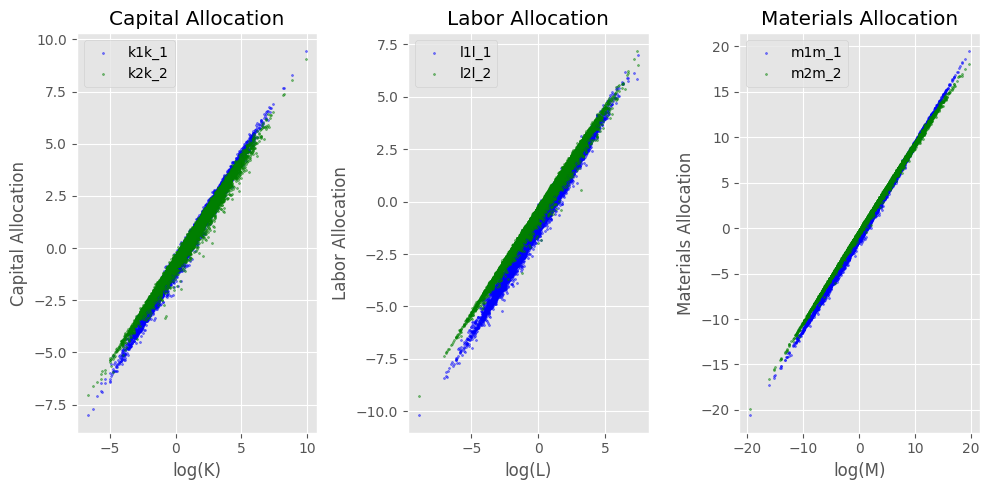

In [31]:
#可视化投入分配（input allocation） 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.scatter(np.log(data[1][:,0:1]), Kopt[0], alpha=0.5, s=2,  label='k1k_1', color='blue')
plt.scatter(np.log(data[1][:,0:1]), Kopt[1], alpha=0.5, s=2, label='k2k_2', color='green')
plt.title('Capital Allocation')
plt.xlabel('log(K)')
plt.legend()
plt.ylabel('Capital Allocation')
plt.subplot(1, 3, 2)
plt.scatter(np.log(data[2][:,0:1]), Lopt[0], alpha=0.5, s=2, label='l1l_1', color='blue')
plt.scatter(np.log(data[2][:,0:1]), Lopt[1], alpha=0.5, s=2, label='l2l_2', color='green')
plt.title('Labor Allocation')
plt.legend()
plt.xlabel('log(L)')
plt.ylabel('Labor Allocation')
plt.subplot(1, 3, 3)
plt.scatter(np.log(data[3][:,0:1]), Mopt[0], alpha=0.5, s=2, label='m1m_1', color='blue')
plt.scatter(np.log(data[3][:,0:1]), Mopt[1], alpha=0.5, s=2, label='m2m_2', color='green')
plt.title('Materials Allocation')
plt.xlabel('log(M)')
plt.ylabel('Materials Allocation')
plt.tight_layout()
plt.legend()
plt.show()

In [32]:
# 通过投入份额（input shares）迭代求解问题 
def mp_input_shares(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # 材料分配参数（material allocation parameter）
    βm_2 = 1.0 - βl_2 - βk_2  # 材料分配参数（material allocation parameter）
    R, K, L, M = data  # 拆包数据（unpack the data）
    n = len(K)  # 企业数量（number of firms）
    Lopt= [0.5*np.ones((n,1)), 0.5*np.ones((n,1))] # 劳动分配的初始猜测值（initial guess）
    Kopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]# 资本分配的初始猜测值（initial guess）
    Mopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]  # 材料分配的初始猜测值（initial guess）
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    
    for i in range(max_iter):
        #计算产出弹性（output elasticities） 
        γ_k = [v_1*βk_1* (Kopt[0]*K)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)), 
                v_2*βk_2* (Kopt[1]*K)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (Lopt[0]*L)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)),
                v_2*βl_2* (Lopt[1]*L)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # 计算投入分配份额（input allocation shares） 
        Kopt_new = [R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])]
        Lopt_new = [R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])]
        Mopt_new = [R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])]
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        
        if (np.linalg.norm(Lopt_new[0] - Lopt[0]) < tol and
            np.linalg.norm(Lopt_new[1] - Lopt[1]) < tol and
            np.linalg.norm(Kopt_new[0] - Kopt[0]) < tol and
            np.linalg.norm(Kopt_new[1] - Kopt[1]) < tol and
            np.linalg.norm(Mopt_new[0] - Mopt[0]) < tol and
            np.linalg.norm(Mopt_new[1] - Mopt[1]) < tol):
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        Lopt = Lopt_new
        Kopt = Kopt_new
        Mopt = Mopt_new
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist

In [33]:
# 通过迭代求解投入分配问题（input allocation problem）
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_shares(params, data)

Converged to input allocations after 11 iterations.
CPU times: total: 15.6 ms
Wall time: 18.5 ms


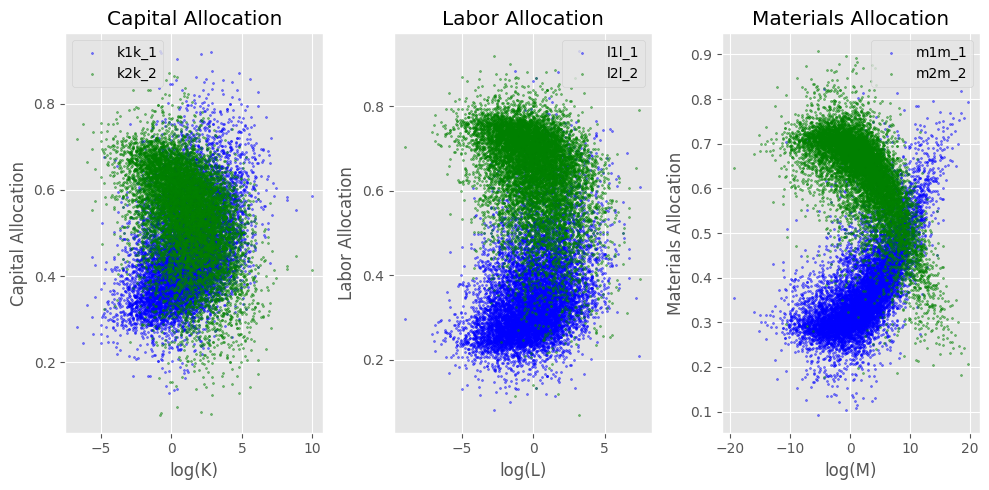

In [34]:
#可视化投入分配（input allocation） 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.scatter(np.log(data[1][:,0:1]), Kopt[0], alpha=0.5, s=2,  label='k1k_1', color='blue')
plt.scatter(np.log(data[1][:,0:1]), Kopt[1], alpha=0.5, s=2, label='k2k_2', color='green')
plt.title('Capital Allocation')
plt.xlabel('log(K)')
plt.legend()
plt.ylabel('Capital Allocation')
plt.subplot(1, 3, 2)
plt.scatter(np.log(data[2][:,0:1]), Lopt[0], alpha=0.5, s=2, label='l1l_1', color='blue')
plt.scatter(np.log(data[2][:,0:1]), Lopt[1], alpha=0.5, s=2, label='l2l_2', color='green')
plt.title('Labor Allocation')
plt.legend()
plt.xlabel('log(L)')
plt.ylabel('Labor Allocation')
plt.subplot(1, 3, 3)
plt.scatter(np.log(data[3][:,0:1]), Mopt[0], alpha=0.5, s=2, label='m1m_1', color='blue')
plt.scatter(np.log(data[3][:,0:1]), Mopt[1], alpha=0.5, s=2, label='m2m_2', color='green')
plt.title('Materials Allocation')
plt.xlabel('log(M)')
plt.ylabel('Materials Allocation')
plt.tight_layout()
plt.legend()
plt.show()

In [35]:
##不同 kappa 取值的实验 
params = mp_input_params(κ_1=0.5, κ_2=3) 
data = mp_data(params, n =1000)
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation(params, data)
%time Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_shares(params, data)

CPU times: total: 234 ms
Wall time: 259 ms
CPU times: total: 188 ms
Wall time: 191 ms


### 修正的定点迭代算法（Modified Fixed-Point Iteration Algorithm）

* 前面的算法直接把映射 $\mathbf{T}$ 应用于投入分配向量（input allocation vector）$\mathbf{x}_{ijt}^*$，而这未必是一个**压缩映射（contraction）**。

* 下面的算法通过放慢迭代速度，并改为对投入份额（input shares）进行迭代：
   $$ s_{ij}^{n+1} = (1-\lambda)s_{ij}^n + \lambda \frac{ P_{ij}Q_{ij}\gamma_j^x(\mathbf{s}_{ij}^{(n)}\bar{X}_{i})}{\sum_{j'}P_{ij'}Q_{ij'}{\gamma}_j^x (\mathbf{s}_{ij'}^{(n)}\bar{X}_{i})}$$
   * 我们选择 $\lambda = \min\{1, \min_{j}\{\frac{\kappa_j}{2|\kappa_j-1|}\}\}$。
   * 虽然尚未证明，但在很宽的 $\kappa_j$ 取值范围内，该算法表现良好。

In [36]:
def mp_input_share2(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # 材料分配参数（material allocation parameter）
    βm_2 = 1.0 - βl_2 - βk_2  # 材料分配参数（material allocation parameter）
    R, K, L, M = data  # 拆包数据（unpack the data）
    n = len(K)  # 企业数量（number of firms）
    Lopt= [0.5*np.ones((n,1)), 0.5*np.ones((n,1))] # 劳动分配的初始猜测值（initial guess）
    Kopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]# 资本分配的初始猜测值（initial guess）
    Mopt = [0.5*np.ones((n,1)), 0.5*np.ones((n,1))]  # 材料分配的初始猜测值（initial guess）
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    
    for i in range(max_iter):
        #计算产出弹性（output elasticities） 
        γ_k = [v_1*βk_1* (Kopt[0]*K)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)), 
                v_2*βk_2* (Kopt[1]*K)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (Lopt[0]*L)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)),
                v_2*βl_2* (Lopt[1]*L)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # 计算投入分配份额（input allocation shares）
        Kopt_new = [R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])]
        Lopt_new = [R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])]
        Mopt_new = [R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])]
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        
        if (np.linalg.norm(Lopt_new[0] - Lopt[0]) < tol and
            np.linalg.norm(Lopt_new[1] - Lopt[1]) < tol and
            np.linalg.norm(Kopt_new[0] - Kopt[0]) < tol and
            np.linalg.norm(Kopt_new[1] - Kopt[1]) < tol and
            np.linalg.norm(Mopt_new[0] - Mopt[0]) < tol and
            np.linalg.norm(Mopt_new[1] - Mopt[1]) < tol):
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        alpha = 0.99* min([1, 0.5*κ_1/abs(κ_1-1), 0.5*κ_2/abs(κ_2-1)])  # 基于 κ 取值的步长（step size）
        Lopt = [alpha*Lopt_new[0] + (1-alpha)*Lopt[0], alpha*Lopt_new[1] +  (1-alpha)*Lopt[1]]
        Kopt = [alpha*Kopt_new[0] + (1-alpha)*Kopt[0], alpha*Kopt_new[1] +  (1-alpha)*Kopt[1]]
        Mopt = [alpha*Mopt_new[0] +  (1-alpha)*Mopt[0], alpha*Mopt_new[1] +  (1-alpha)*Mopt[1]]
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist    
        
def mp_input_allocation2(params, data, tol=1e-5, max_iter=1000):
    βl_1, βl_2, βk_1, βk_2, κ_1, κ_2, v_1, v_2 = params
    βm_1 = 1.0 - βl_1 - βk_1  # 材料分配参数（material allocation parameter）
    βm_2 = 1.0 - βl_2 - βk_2  # 材料分配参数（material allocation parameter）
    R, K, L, M = data  # 拆包数据（unpack the data）
    Lopt= [0.5*np.log(L), 0.5*np.log(L)] # 劳动分配的初始猜测值（initial guess）
    Kopt = [0.5*np.log(K), 0.5*np.log(K)] # 资本分配的初始猜测值（initial guess）
    Mopt = [0.5*np.log(M), 0.5*np.log(M)]  # 材料分配的初始猜测值（initial guess）
    Llist = [Lopt.copy()]
    Klist = [Kopt.copy()]
    Mlist = [Mopt.copy()]
    for i in range(max_iter):
        #计算产出弹性（output elasticities） 
        γ_k = [v_1*βk_1* (np.exp(Kopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)), 
                v_2*βk_2* (np.exp(Kopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_l = [v_1*βl_1* (np.exp(Lopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0]))**(1-1/κ_1)),
                v_2*βl_2* (np.exp(Lopt[1]))**(1-1/κ_2)/(βk_2*(np.exp(Kopt[1]))**(1-1/κ_2) +βl_2*(np.exp(Lopt[1]))**(1-1/κ_2) + βm_2*(np.exp(Mopt[1]))**(1-1/κ_2))]
        γ_m = [v_1 - γ_k[0] - γ_l[0], v_2 - γ_k[1] - γ_l[1]]
        # 计算投入分配（input allocations） 
        Kopt_new = np.log([K*R[:, 0:1]*γ_k[0]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1]), K*R[:,1:2]*γ_k[1]/(R[:,0:1]*γ_k[0] + R[:,1:2]*γ_k[1])])
        Lopt_new = np.log([L*R[:,0:1]*γ_l[0]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1]), L*R[:,1:2]*γ_l[1]/(R[:,0:1]*γ_l[0] + R[:,1:2]*γ_l[1])])
        Mopt_new = np.log([M*R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), M*R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])])
        Llist.append(Lopt_new.copy())
        Klist.append(Kopt_new.copy())
        Mlist.append(Mopt_new.copy())
        if np.linalg.norm(Lopt_new - Lopt) < tol and np.linalg.norm(Kopt_new - Kopt) < tol and np.linalg.norm(Mopt_new-Mopt) < tol:
            print("Converged to input allocations after {} iterations.".format(len(Llist)))
            return Lopt_new, Kopt_new, Mopt_new, Llist, Klist, Mlist
        alpha = 0.99* min([1, 0.5*κ_1/abs(κ_1-1), 0.5*κ_2/abs(κ_2-1)])  # 基于 κ 取值的步长（step size）
        Lopt = [alpha*Lopt_new[0] + (1-alpha)*Lopt[0], alpha*Lopt_new[1] +  (1-alpha)*Lopt[1]]
        Kopt = [alpha*Kopt_new[0] + (1-alpha)*Kopt[0], alpha*Kopt_new[1] +  (1-alpha)*Kopt[1]]
        Mopt = [alpha*Mopt_new[0] +  (1-alpha)*Mopt[0], alpha*Mopt_new[1] +  (1-alpha)*Mopt[1]]
    
        if i == max_iter - 1:
            print("Warning: Maximum iterations reached without convergence.")
            return Lopt, Kopt, Mopt, Llist, Klist, Mlist

In [37]:
import time
kappa1_list = np.arange(0.1, 6, 0.2)
kappa2_list = np.arange(0.1, 6, 0.2)
results = []
for κ_1 in kappa1_list:
    for κ_2 in kappa2_list:
        params = mp_input_params(κ_1=κ_1, κ_2=κ_2)
        data = mp_data(params, n=1000)
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_share2(params, data)
        iter1 = len(Llist)
        if iter1 < 1000:
            converged1 = True
        else:
            converged1 = False
        elapsed1 = time.time() - start
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_shares(params, data)
        iter2 = len(Llist)
        if iter2 < 1000:
            converged2 = True
        else:
            converged2 = False
        elapsed2 = time.time() - start
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation2(params, data)
        iter3 = len(Llist)
        if iter3 < 1000:
            converged3 = True
        else:
            converged3 = False
        elapsed3 = time.time() - start
        start = time.time()
        Lopt, Kopt, Mopt, Llist, Klist, Mlist = mp_input_allocation(params, data)
        elapsed4 = time.time() - start
        iter4 = len(Llist)
        if iter4 < 1000:
            converged4 = True
        else:
            converged4 = False
        elapsed4 = time.time() - start
               
        results.append({
            'κ_1': κ_1,
            'κ_2': κ_2,
            'iterations1': iter1,
            'iterations2': iter2,
            'iterations3': iter3,
            'iterations4': iter4,
            'converged3': converged3,
            'converged1': converged1,
            'converged2': converged2,
            'converged4': converged4,
            'time1': elapsed1,
            'time2': elapsed2,
            'time3': elapsed3,
            'time4': elapsed4
        })

C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2919707248.py:24: RuntimeWarning: invalid value encountered in divide
  Mopt_new = [R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])]


C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2530616630.py:25: RuntimeWarning: invalid value encountered in divide
  Mopt_new = [R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])]
C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2530616630.py:17: RuntimeWarning: divide by zero encountered in power
  γ_k = [v_1*βk_1* (Kopt[0]*K)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)),
C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2530616630.py:18: RuntimeWarning: divide by zero encountered in power
  v_2*βk_2* (Kopt[1]*K)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2530616630.py:19: RuntimeWarning: divide by zero encountered in power
  γ_l = [v_1*βl_1* (Lopt[0]*L)**(1-1/κ_1)/(βk_1*(Kopt[0]*K)**(1-1/κ_1) +βl_1*(Lopt[0]*L)**(1-1/κ_1) + βm_1*(Mopt[0]*M)**(1-1/κ_1)),
C:\Users\Don\AppDat

C:\Users\Don\AppData\Local\Temp\ipykernel_33960\571982341.py:40: RuntimeWarning: invalid value encountered in divide
  Mopt_new = np.log([M*R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), M*R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])])
C:\Users\Don\AppData\Local\Temp\ipykernel_33960\571982341.py:40: RuntimeWarning: divide by zero encountered in log
  Mopt_new = np.log([M*R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), M*R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])])
C:\Users\Don\AppData\Local\Temp\ipykernel_33960\571982341.py:40: RuntimeWarning: invalid value encountered in log
  Mopt_new = np.log([M*R[:,0:1]*γ_m[0]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1]), M*R[:,1:2]*γ_m[1]/(R[:,0:1]*γ_m[0] + R[:,1:2]*γ_m[1])])
C:\Users\Don\AppData\Local\Temp\ipykernel_33960\571982341.py:32: RuntimeWarning: divide by zero encountered in power
  γ_k = [v_1*βk_1* (np.exp(Kopt[0]))**(1-1/κ_1)/(βk_1*(np.exp(Kopt[0]))**(1-1/κ_1) +βl_1*(np.exp(Lopt[0]))**(1-1/κ_1) + βm_1*(np.exp(Mopt[0])

C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2530616630.py:18: RuntimeWarning: invalid value encountered in power
  v_2*βk_2* (Kopt[1]*K)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]
C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2530616630.py:20: RuntimeWarning: invalid value encountered in power
  v_2*βl_2* (Lopt[1]*L)**(1-1/κ_2)/(βk_2*(Kopt[1]*K)**(1-1/κ_2) +βl_2*(Lopt[1]*L)**(1-1/κ_2) + βm_2*(Mopt[1]*M)**(1-1/κ_2))]


Converged to input allocations after 225 iterations.


...

Converged to input allocations after 133 iterations.
Converged to input allocations after 77 iterations.
Converged to input allocations after 106 iterations.
Converged to input allocations after 61 iterations.


Converged to input allocations after 133 iterations.
Converged to input allocations after 77 iterations.
Converged to input allocations after 108 iterations.
Converged to input allocations after 63 iterations.


Converged to input allocations after 132 iterations.
Converged to input allocations after 77 iterations.
Converged to input allocations after 110 iterations.
Converged to input allocations after 64 iterations.


Converged to input allocations after 132 iterations.
Converged to input allocations after 77 iterations.
Converged to input allocations after 112 iterations.
Converged to input allocations after 65 iterations.


Converged to input allocations after 135 iterations.
Converged to input allocations after 78 iterations.


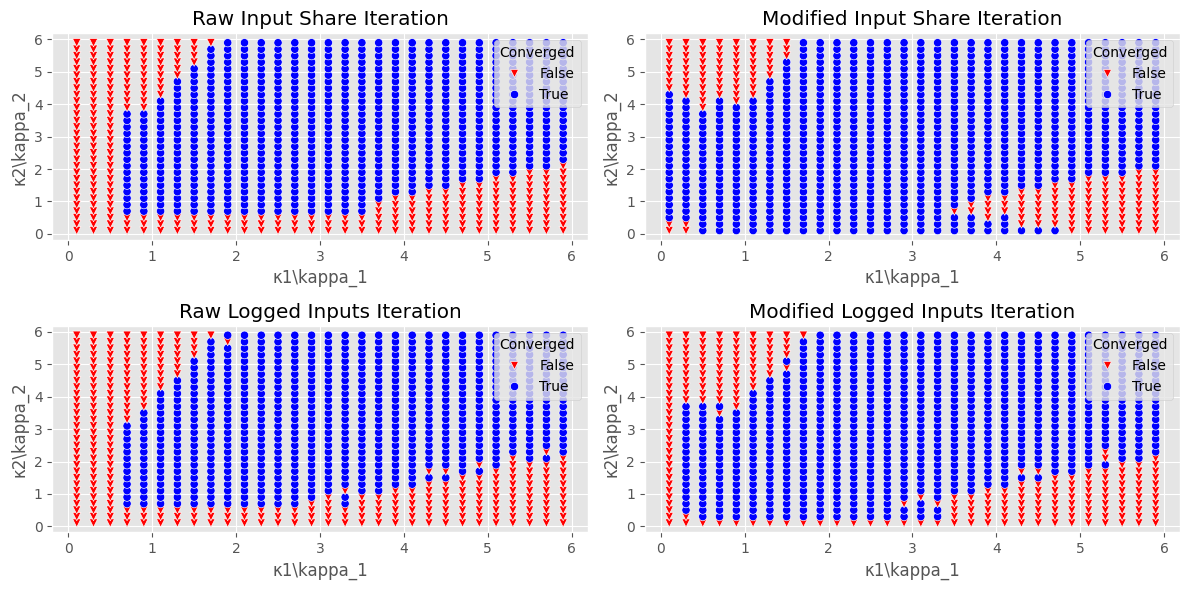

In [38]:
import pandas as pd 
import seaborn as sns
df_results = pd.DataFrame(results)
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 2)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged1',
	style='converged1',
	markers={True: 'o', False: 'v'},  # 两类标记都使用填充样式（filled markers）
	palette={True: 'blue', False: 'red'}
)
plt.title('Modified Input Share Iteration')
plt.xlabel(r'κ1\kappa_1')
plt.ylabel(r'κ2\kappa_2')
plt.legend(title='Converged', loc='upper right')
plt.subplot(2, 2, 1)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged2',
	style='converged2',
	markers={True: 'o', False: 'v'},  # 两类标记都使用填充样式（filled markers）
	palette={True: 'blue', False: 'red'}
)
plt.title('Raw Input Share Iteration')
plt.xlabel(r'κ1\kappa_1')
plt.ylabel(r'κ2\kappa_2')
plt.legend(title='Converged', loc='upper right')
plt.subplot(2, 2, 4)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged3',
	style='converged3',
	markers={True: 'o', False: 'v'},  # 两类标记都使用填充样式（filled markers）
	palette={True: 'blue', False: 'red'}
)
plt.title('Modified Logged Inputs Iteration')
plt.xlabel(r'κ1\kappa_1')
plt.ylabel(r'κ2\kappa_2')
plt.legend(title='Converged', loc='upper right')
plt.subplot(2, 2, 3)
sns.scatterplot(
	data=df_results,
	x='κ_1',
	y='κ_2',
	hue='converged4',
	style='converged4',
	markers={True: 'o', False: 'v'},  # 两类标记都使用填充样式（filled markers）
	palette={True: 'blue', False: 'red'}
)
plt.title('Raw Logged Inputs Iteration')
plt.xlabel(r'κ1\kappa_1')
plt.ylabel(r'κ2\kappa_2')
plt.legend(title='Converged', loc='upper right')
plt.tight_layout()

plt.show()

> **练习 1：计算 Cournot 博弈（Computing the Cournot Game）**

考虑如下设置下的 Cournot 双寡头（Cournot Duopoly）：
* 产品需求为 CES：$P(q) = q^{-1/\eta}$，其中 $q = q_1 + q_2$。
* 每家企业有二次成本（quadratic costs）：$C_i(q) = \frac{1}{2} c_i q_i^2$，$i = 1,2$。于是企业 $i$ 求解如下最大化问题：$$ \max_{q_i} P(q_i + q_{-i})q_i - C_i(q_i) $$
通过同时求解两家企业的一阶条件（first order conditions）来找到该模型的均衡（equilibrium）。这些条件对 $i = 1,2$ 构成非线性方程（nonlinear equations）：$$f_i(q) = (q_i + q_{-i})^{-1/\eta} - (1/\eta)(q_i + q_{-i})^{-1/\eta-1}q_i- c_iq_i = 0$$
* **参数（Parameters）**：$[c_1, c_2, \eta] = [0.3, 0.6, 2];$

你需要：
  1. 自己编写牛顿法（Newton's method）代码来求解非线性方程组（system of nonlinear equations）。
  2. 通过寻找不动点（fixed point，即 Nash equilibrium）尝试直接迭代方法（direct iteration method），并使用不同初始值进行实验。请结合**压缩映射理论（theory of contraction mappings）**解释你的结果。
  3. 使用 `scipy.optimize.fsolve` 函数求解方程组。
  4. 现在假设政府通过把企业 2 的生产成本降低为 $C_2(q) = 0.9\times \frac{1}{2} c_2 q_i^2 $ 来补贴企业 2。均衡会如何变化？

## 经济学中的结构估计简介（Introduction to Structural Estimation in Economics）
***

### 约化式方法与结构方法初识（Reduced-form and Structural Methods）
***
#### 约化式方法（Reduced-form Methods）：
  - 关注估计处理变量（treatment, $X$）对结果变量（outcome, $Y$）的因果效应（causal effect）。
  
  - 不显式建模底层机制（underlying mechanisms）。
  
  - 例如 OLS、IV、RDD、matching 等。

#### 结构方法（Structural Methods）：
  - 关注估计一个模型的结构参数（structural parameters），该模型描述 $X$ 和 $Y$ 之间的关系。
  
  - 显式建模底层机制（underlying mechanisms）。
  
  - 用于政策评估（policy evaluation）和福利分析（welfare analysis）的反事实分析（counterfactual analysis）。
  
  - 例如需求估计（demand estimation）、动态规划（dynamic programming）、定量贸易模型（quantitative trade models）等。

### 连接模型与数据：比较（Connecting Model to Data: A Comparison）
***


| 特征（Features） | 约化式模型（Reduced-form Model） | 结构模型（Structural Model） |
|:---------:|:------------------:|:--------------------:|
| *数据生成过程（Data Generation Process）* |$Y_i = f(X_i) + \varepsilon_i$ | $X_i = \operatorname*{arg\,max}_{z} \{U(Y_i, z)\}$|
| *估计目的（Estimation Purpose）*| $X$ 对 $Y$ 的因果效应（causal effect） | 模型的结构参数（structural parameters） |
| *估计方法（Estimation Method）* | OLS、IV、RDD、Matching | SMM、MLE、MCMC |
| *优点（Advantages）* | 易于实现、解释和理解 | 更灵活，可纳入更多信息，可用于反事实分析（counterfactual analysis） |
| *缺点（Disadvantages）* | 机制？误设（mis-specification）？一般均衡效应（general equilibrium effects）？ | 通常更复杂，需要更多假设，存在过拟合问题（overfitting problem）|

### 结构估计的常规流程（Routine Procedures of Structural Estimation）

1. **模型设定（Model Specification）**：定义经济模型及其结构参数（structural parameters）。
   - 示例：需求估计（demand estimation）、生产函数估计（production function estimation）等。
2. **数据收集（Data Collection）**：收集与模型相关的数据。

3. **模型估计（Model Estimation）**：使用数据估计结构参数。
   - 方法：模拟矩量法（simulated method of moments, SMM）、极大似然估计（maximum likelihood estimation, MLE）、贝叶斯方法（Bayesian methods）等。

4. **模型验证（Model Validation）**：检查模型对数据的拟合程度（fit）及其预测能力（predictive power）。

5. **反事实分析（Counterfactual Analysis）**：使用估计后的模型进行反事实分析和政策评估（policy evaluation）。
   - 示例：模拟政策变化对结果变量的影响。

6. **敏感性分析（Sensitivity Analysis）**：检查结果对不同假设和设定（specifications）的稳健性。

### 结构估计中的基本概念（Basic Concepts in Structural Estimation）

> **模型（Model）**：**模型（model）**是一组因果数学关系（cause and effect mathematical relationships），通常用参数 $\theta$ 表示，用于在数据 $x$ 或 $(x,y)$ 之间理解、解释和预测现象。模型可以写作：
$$
g(x,\theta)=0 \quad\text{or}\quad y=g(x,\theta).
$$
其中 $g$ 是一个函数或函数向量，表示变量与参数之间的数学关系。

> **外生变量（Exogenous Variable）**：**外生变量（exogenous variables）**是模型的输入，被视为给定，或来自模型之外。这些变量可以包括数据 $x$ 和参数 $\theta$。

> **内生变量（Endogenous variables）**是模型的输出，或依赖外生变量的变量。这些变量可以包括数据 $x$ 的一部分，有时在 $y = g(x,\theta)$ 中记为 $y$。

## 结构估计中的估计方法（Estimation Methods in Structural Estimation）
***
### 极大似然估计（Maximum Likelihood Estimation, MLE）

### 广义矩量法（Generalized Method of Moments, GMM）

### 模拟矩量法（Simulated Method of Moments, SMM）

**参考资料（Reference）**：https://opensourceecon.github.io/CompMethods/struct_est/intro.html

### 极大似然估计（Maximum Likelihood Estimation, MLE）
***
 定义一个模型或**数据生成过程（data generating process, DGP）**为：
$$
F(x_t, z_t|\theta) = 0
$$
其中 $x_t$ 和 $z_t$ 是变量，$\theta$ 是参数向量（vector of parameters），$F(\cdot)$ 是刻画它们关系的函数。

* **MLE**：选择模型的参数向量 $\theta$，使模型 $F(x_t, z_t|\theta) = 0$ 生成所观察数据 $(x_t, z_t)$ 的似然（likelihood）最大。

* `Rust (1987)` 使用 MLE（结合嵌套定点迭代，nested fixed-point iteration）估计公交车发动机更换动态规划模型（dynamic programming model）的参数。[`Python Package`](https://ruspy.readthedocs.io/en/latest/index.html)

### MLE 示例：正态分布（Normal Distribution）
* 对正态分布（normal distribution），（统计）模型使用概率密度函数（probability density function, PDF）定义：$$
    f(x|\theta) = f(x|\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x - \mu)^2}{2\sigma^2}} $$
其中 $\theta = (\mu, \sigma)$，$\mu$ 是均值（mean），$\sigma$ 是标准差（standard deviation）。

* 在 *i.i.d* 假设下，把来自模型或分布 $f(x|\theta)$ 的 $N$ 次抽样 $(x_1,x_2,...x_N)$ 的似然函数（likelihood function）定义为 $\mathcal{L}$。$$  \mathcal{L}(x_1,x_2,...x_N|\theta) \equiv \prod_{i=1}^N f(x_i|\theta)$$

* 通常使用对数似然函数（log likelihood function）$\ln(\mathcal{L})$ 更方便。
 $$  \ln\Bigl(\mathcal{L}(x_1,x_2,...x_N|\theta)\Bigr) \equiv \sum_{i=1}^N \ln\Bigl(f(x_i|\theta)\Bigr)$$

In [39]:
#正态分布（normal distribution）的 MLE 示例
#参数化（parameterization） 
normal_params = namedtuple("normal_params", ('mu', 'sigma'))
def create_normal_params(mu=1.5, sigma=3.5):
    return normal_params(mu=mu, sigma=sigma)
#生成数据
def generate_data(mu, sigma, n=1000):
    np.random.seed(42)  # 设置随机种子以保证可复现性（reproducibility）
    data = np.random.normal(mu, sigma, n)
    return data
#对数似然函数（log likelihood function）
def log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:  # 确保 sigma 为正
        return np.inf
    n = len(data)
    ll = -n/2 * np.log(2 * np.pi) - n * np.log(sigma) - np.sum((data - mu)**2) / (2 * sigma**2)
    return -ll  # 返回负对数似然（negative log likelihood），用于最小化

In [40]:
#使用 scipy.optimize 库求解 MLE
from scipy.optimize import minimize
params_true = create_normal_params(mu=1, sigma=3)
data = generate_data(params_true.mu, params_true.sigma, n=5000)
initial_params = create_normal_params(mu=0.8, sigma=2)
mle_res = minimize(
    log_likelihood, 
    x0=np.array([initial_params.mu, initial_params.sigma]), 
    args=(data,),
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-6, None))  # sigma 必须为正
)
print(mle_res)
print("True parameters (mu, sigma)=({:.4f}, {:.4f})".format(params_true.mu, params_true.sigma))
print("Estimated (mu, sigma)=({:.4f}, {:.4f})".format(mle_res.x[0], mle_res.x[1]))

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 12569.622155527439
        x: [ 1.017e+00  2.989e+00]
      nit: 5
      jac: [-4.002e-03  9.404e-02]
     nfev: 18
     njev: 6
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
True parameters (mu, sigma)=(1.0000, 3.0000)
Estimated (mu, sigma)=(1.0168, 2.9892)


C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2588089457.py:6: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  mle_res = minimize(


### 广义矩量法（Generalized Method of Moments, GMM）

* GMM 最早由 Hansen (1982) 形式化提出。GMM 估计的一个优点是，计量经济学家可以不对数据生成过程（DGP）中随机变量的分布作具体假设。

> **数据/模型矩（Data/Model Moment）**：数据/模型的矩（moment）可宽泛地定义为某种概括数据/模型的统计量（statistic），例如均值（mean）、方差（variance）、协方差（covariance）等。

$$
\begin{aligned}
\text{data moments: }  & m(x) \equiv [m_1(x),m_2(x),\ldots,m_\ell(x)]^\top, \\
\text{model moments: } & m(x|\theta) \equiv [m_1(x|\theta),m_2(x|\theta),\ldots,m_\ell(x|\theta)]^\top.
\end{aligned}
$$

**GMM 估计（GMM Estimation）**：选择 $\theta$，使模型矩 $m(x|\theta)$ 与数据矩 $m(x)$ 之间的距离最小：

$$
\|m(x|\theta)-m(x)\|.
$$

### GMM 估计量与两步 GMM（GMM Estimator and Two-Step GMM）

定义 $e(x|\theta)\equiv m(x|\theta)-m(x)$，则 GMM 估计量为

$$
\hat{\theta}_{GMM}
=\operatorname*{arg\,min}_{\theta} e(x|\theta)^\top W e(x|\theta),
$$

其中 $W$ 是准则函数（criterion function）中的 $\ell\times\ell$ 加权矩阵（weighting matrix）。

#### 加权矩阵的选择（Choice of Weighting Matrix）

* 单位矩阵（identity matrix）$W=I_\ell$ 是一种常见选择，但它没有考虑矩的方差。
* 最优加权矩阵（optimal weighting matrix）由矩误差协方差矩阵的逆给出。

#### 两步 GMM 估计量（Two-Step GMM Estimator）

1. 使用 $W=I$ 得到第一步估计 $\hat{\theta}_{1,GMM}$。
2. 用第一步矩误差估计协方差矩阵并构造 $\widehat W$，再重新估计。

迭代 GMM 重复第二步，直到

$$
\|\widehat W^{(k+1)}-\widehat W^{(k)}\|<\varepsilon.
$$

#### GMM 中的推断（Inference in GMM）

使用 Delta 方法（delta method），GMM 估计量的渐近分布可写为

$$
\sqrt{N}(\hat\theta_{GMM}-\theta_0)
\xrightarrow{d}
N\left(0,
\left[\frac{\partial e(x|\theta)}{\partial\theta}^\top
W
\frac{\partial e(x|\theta)}{\partial\theta}\right]^{-1}
\right).
$$

### GMM 示例：正态分布（Normal Distribution）

对正态分布（normal distribution）生成的数据，我们选择均值（mean）和标准差（standard deviation）作为矩（moments）：

$$
\begin{aligned}
\text{data: } & m(x)=\left[\frac{1}{n}\sum_i X_i,\sqrt{\frac{1}{n}\sum_i(X_i-\bar X)^2}\right]^\top, \\
\text{model: } & m(\theta)=[\mu,\sigma]^\top.
\end{aligned}
$$

GMM 目标函数（objective function）为

$$
\hat\theta_{GMM}
=\operatorname*{arg\,min}_{\theta}
[m(\theta)-m(x)]^\top W [m(\theta)-m(x)].
$$

* 尝试两步 GMM（Two-Step GMM）和迭代 GMM（Iterative GMM）。

In [41]:
#正态分布（normal distribution）的 GMM 估计 
def gmm_objective(params, data):
    """使用单位权重矩阵（identity weighting）的目标函数"""
    mu, sigma = params
    if sigma <= 0:  # 确保 sigma 为正
        return np.inf
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return np.sum(moments**2)
def gmm_weight(params, data):
    """GMM 的权重矩阵（weighting matrix）"""
    mu, sigma = params
    n = len(data)
    moments_matrix = np.stack([
        data - mu,
        (data - mu)**2 - sigma**2
    ], axis=1)
    Omega =1/n * np.cov(moments_matrix, rowvar=False)
    return np.linalg.pinv(Omega)  # 用伪逆更稳健    
def gmm_iter_objective(params, data, W):
    """使用一般权重矩阵（general weighting matrix）的目标函数"""
    mu, sigma = params
    if sigma <= 0:  # 确保 sigma 为正
        return np.inf
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return moments.T @ W @ moments

In [42]:
# 两步 GMM 估计（two-step GMM estimation） 
params_init = create_normal_params(mu=0.8, sigma=2)
x0 = np.array([params_init.mu, params_init.sigma])
# 第一步：使用单位权重矩阵（identity weighting matrix）
gmm_res1 = minimize(
    gmm_objective, 
    x0=x0, 
    args=(data,), 
    method='L-BFGS-B', 
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-8, None))  # sigma 必须为正
)
print("First step GMM results:", gmm_res1)

First step GMM results:   message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 1.1931320913300125e-15
        x: [ 1.017e+00  2.989e+00]
      nit: 11
      jac: [-4.353e-10 -5.086e-08]
     nfev: 36
     njev: 12
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


C:\Users\Don\AppData\Local\Temp\ipykernel_33960\1920830410.py:5: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  gmm_res1 = minimize(


In [43]:
#第二步：计算权重矩阵（weighting matrix）并重新估计
W = gmm_weight(gmm_res1.x, data)
print("Estimated Second-Step Weighting Matrix:\n", W)
gmm_res2 = minimize(
    gmm_iter_objective, 
    x0=gmm_res1.x, 
    args=(data, W), 
    method='L-BFGS-B', 
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-8, None))  # sigma 必须为正
)
print("Second step GMM results:", gmm_res2)
print("Weighting Matrix:\n", gmm_weight(gmm_res2.x, data))

Estimated Second-Step Weighting Matrix:
 [[559.52662993   1.09441854]
 [  1.09441854  30.69346586]]
Second step GMM results:   message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 5.140816272492457e-14
        x: [ 1.017e+00  2.989e+00]
      nit: 0
      jac: [-3.183e-07 -1.629e-06]
     nfev: 3
     njev: 1
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
Weighting Matrix:
 [[559.52662993   1.09441854]
 [  1.09441854  30.69346586]]


C:\Users\Don\AppData\Local\Temp\ipykernel_33960\835025588.py:4: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  gmm_res2 = minimize(


In [44]:
# GMM 估计量的推断（inference）
### 计算矩条件（moments）关于参数的导数
import autograd.numpy as np
from autograd import jacobian
def gmm_moments(params):
    mu, sigma = params
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return moments
#使用 autograd 计算矩条件的雅可比矩阵（Jacobian）
gmm_jacobian = jacobian(gmm_moments)  # 计算关于第一个参数（params）的雅可比矩阵（Jacobian）
gmm_jacobian_val = gmm_jacobian(gmm_res2.x)  # 在估计参数处计算雅可比矩阵（Jacobian）  
print(gmm_jacobian_val)

[[-1.          0.        ]
 [ 0.         -5.97828104]]


In [45]:
def gmm_vc(data, params):
    W = gmm_weight(gmm_res2.x, data)
    n = len(data)
    gmm_delta = gmm_jacobian(params)  # 在估计参数处计算雅可比矩阵（Jacobian）
    CV = 1/n * np.linalg.inv(gmm_delta.T @ W @ gmm_delta)
    return CV
# 计算方差-协方差矩阵（variance-covariance matrix）
theta_vc = gmm_vc(data, gmm_res2.x)
#生成估计参数及其标准误（standard errors）的表格
def gmm_results_table(params, vc_matrix):
    mu, sigma = params
    std_errors = np.sqrt(np.diag(vc_matrix))
    results = pd.DataFrame({
        'Parameter': ['mu', 'sigma'],
        'Estimate': [mu, sigma],
        'Std. Error': std_errors
    })
    return results

results_table = gmm_results_table(gmm_res2.x, theta_vc)
print("------Two-Step GMM Results-------")
print("---------------------------------")
print(results_table)

------Two-Step GMM Results-------
---------------------------------
  Parameter  Estimate  Std. Error
0        mu  1.016806    0.000598
1     sigma  2.989141    0.000427


In [46]:
#迭代 GMM 估计（iterative GMM estimation） 
def iterative_gmm_objective(params, data, W):
    """迭代 GMM 的目标函数"""
    mu, sigma = params
    if sigma <= 0:  # 确保 sigma 为正
        return np.inf
    n = len(data)
    m1 = np.mean(data) - mu
    m2 = np.var(data) - sigma**2
    moments = np.array([m1, m2])
    return moments.T @ W @ moments

Tol = 1e-8
def iterative_gmm_estimation(data, params_init, tol=Tol, max_iter=1000):
    """带收敛检查（convergence check）的迭代 GMM 估计"""
    params = np.array([params_init.mu, params_init.sigma])
    W = gmm_weight(params, data)
    for i in range(max_iter):
        res = minimize(
            iterative_gmm_objective, 
            x0=params, 
            args=(data, W), 
            method='L-BFGS-B', 
            options={'disp': True, 'maxiter': 10000}, 
            bounds=((None, None), (1e-8, None))  # sigma 必须为正
        )
        new_params = res.x
        new_W = gmm_weight(new_params, data)
        if np.linalg.norm(new_W - W) < tol:
            print(f"Converged after {i+1} iterations.")
            return new_params
        params = new_params
        W = new_W # 更新权重矩阵（weighting matrix）
    print("Warning: Maximum iterations reached without convergence.")
    return params

In [47]:
# 迭代 GMM 估计结果 
iterative_params = iterative_gmm_estimation(data, params_init)
# 计算迭代 GMM 的方差-协方差矩阵（variance-covariance matrix）
theta_vc_iterative = gmm_vc(data, iterative_params)
# 生成迭代 GMM 估计参数及其标准误（standard errors）的表格
iterative_results_table = gmm_results_table(iterative_params, theta_vc_iterative)
print("------Iterative GMM Results-------")
print("---------------------------------")
print(iterative_results_table)

Converged after 2 iterations.
------Iterative GMM Results-------
---------------------------------
  Parameter  Estimate  Std. Error
0        mu  1.016806    0.000598
1     sigma  2.989141    0.000427


C:\Users\Don\AppData\Local\Temp\ipykernel_33960\2007899843.py:19: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


### 模拟矩量法（Simulated Method of Moments, SMM）
***
* **SMM** 是 GMM 估计量的一种特殊类型。
* **核心思想（Main Idea）**：SMM 估计量选择模型参数向量 $\theta$，使模拟模型矩（simulated model moments）匹配数据矩（data moments）：
$$\hat{\theta}_{SMM}=\operatorname*{arg\,min}_{\theta}\: \|\hat{m}(\tilde{x}|\theta)-m(x)\|$$
   其中 $\hat{m}(\tilde{x}|\theta)$ 是基于模型参数 $\theta$ 和模拟数据（simulated data）$\tilde{x}$ 得到的模拟模型矩。

* **模拟模型矩（Simulated Model Moments）**：模拟模型矩 $\hat{m}(\tilde{x}|\theta)$ 使用与 GMM 中相同的矩函数（moment functions），从模拟数据 $\tilde{x}$ 中计算得到。

* 目标函数（objective function）、加权矩阵（weighting matrix）和推断（inference）与 GMM 类似，唯一区别是使用**模拟数据（simulated data）** $\tilde{x}$ 而不是实际数据 $x$。

* **示例（Example）**：`Eaton et al. (2012, Econometrica)` 使用 SMM 来量化国际贸易中的 Melitz 模型（Melitz model）。[参考 slides（Reference Slides）](https://gitee.com/zhiyuanryanchen/econ-research-methods/tree/master/2020Fall/Lecture5)

### 基于矩估计中的识别（Identification in Moments-Based Estimation）

**识别的一般规则（General Rules of Identification）**：设参数向量 $\theta$ 有 $k$ 个元素，或者说有 $k$ 个需要估计的参数。为了用 GMM 估计 $\theta$，矩的数量至少应不少于参数数量，即 $\ell \geq k$。

* **恰好识别（Exact Identification）**：$\ell = k$，模型是*恰好识别（exactly identified）*的。
* **过度识别（Over Identified）**：$\ell > k$，模型是*过度识别（overidentified）*的。
* **识别不足（Under Identified）**：$\ell <k$，模型是*识别不足（underidentified）*的。
  
在 SMM 估计中，正如前一个例子所示，有充分理由让模型过度识别（over-identify）$\ell>k$：
* 有些矩传递的信息大致相同，**并不能分别识别任何额外参数**。

* **外部矩验证（Outside moment validation）**：从估计中未使用的数据中取出某个矩，观察估计模型中对应的矩匹配得如何。

> **矩的选择（Selection of Moments）**：选择用于 SMM 参数估计的矩，需要**理解模型、把握模型与现实世界连接的直觉，并带有一定艺术性**。

In [48]:
# 使用 SMM 估计正态分布（normal distribution）参数 
def smm_objective(params, data):
    """为 SMM 模拟矩（simulate moments）"""
    mu, sigma = params
    np.random.seed(42)  # 设置随机种子以保证可复现性（reproducibility）
    n = 10000  # 模拟数据点数量（number of simulated data points）
    simulated_data = np.random.normal(mu, sigma, n)
    m1 = np.mean(simulated_data) - np.mean(data)
    m2 = np.var(simulated_data) - np.var(data)
    moments = np.array([m1, m2])
    return np.sum(moments**2)
# SMM 估计
smm_res = minimize(
    smm_objective, 
    x0=np.array([params_init.mu, params_init.sigma]), 
    args=(data,), 
    method='L-BFGS-B', 
    options={'disp': True, 'maxiter': 10000}, 
    bounds=((None, None), (1e-8, None))  # sigma 必须为正
)
print("SMM results:", smm_res)
# 计算 SMM 的方差-协方差矩阵（variance-covariance matrix）

SMM results:   message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 1.6588128498171702e-12
        x: [ 1.023e+00  2.979e+00]
      nit: 9
      jac: [-2.557e-06 -9.456e-07]
     nfev: 30
     njev: 10
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


C:\Users\Don\AppData\Local\Temp\ipykernel_33960\3353531079.py:13: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  smm_res = minimize(


## 附录（Appendix）
***

### 1. Broyden 方法中的雅可比矩阵（Jacobian Matrix in Broyden Method）
***
<a id="Jacobian-Matrix-in-Broyden's-Method"></a>

给定：
- 矩阵 $J^{(k)} \in \mathbb{R}^{n \times n}$，
- 向量 $\Delta x^{(k)} \equiv x^{(k)}-x^{(k-1)}, \Delta f^{(k)}\equiv f({x^{(k)}})-f(x^{(k-1)}) \in \mathbb{R}^n$，
- 残差向量（residual vector）$r_k := J^{(k+1)}\cdot\Delta f^{(k)} - J^{(k)}\cdot \Delta f^{(k)} \in \mathbb{R}^n$，

我们想找到一个矩阵 $\Delta J^{(k)} \in \mathbb{R}^{n \times n}$，使其：

1. **满足约束（Satisfies the constraint）**：
   $$
   \Delta J^{(k)} \cdot \Delta f^{(k)} = r_k
   $$

2. **最小化 Frobenius 范数（Minimizes the Frobenius norm）**：
   $$
   \min_{\Delta J^{(k)}} \|\Delta J^{(k)}\|_F^2
   $$

这是一个约束优化问题（constrained optimization problem）。

***
#### 第 1 步：向量化问题（Vectorizing the Problem）

考虑 Frobenius 范数（Frobenius norm）：
$$
\|\Delta J^{(k)}\|_F^2 = \text{tr}((\Delta J^{(k)})^\top \Delta J^{(k)}) = \sum_{i,j} [\Delta J^{(k)}]_{ij}^2
$$

我们在如下约束下最小化它：
$$
\Delta J^{(k)} \Delta f^{(k)} = r_k
$$

记作：$A := \Delta J^{(k)}$，$y := \Delta f^{(k)}$，$r := r_k$。

***
#### 第 2 步：使用拉格朗日乘子（Use Lagrange Multipliers）

构造拉格朗日函数（Lagrangian）：
$$
\mathcal{L}(A, \lambda) = \frac{1}{2} \|A\|_F^2 - \lambda^\top (A y - r)
$$
其中 $\lambda \in \mathbb{R}^n$ 是拉格朗日乘子向量（Lagrange multiplier vector）。

***
#### 第 3 步：对 $A$ 求导（Take Derivative w.r.t. $A$）

下列项的导数为：
- $\frac{1}{2} \|A\|_F^2 = \frac{1}{2} \text{tr}(A^\top A)$ 关于 $A$ 的导数是 $A$，
- $\lambda^\top A y = \text{tr}(\lambda y^\top A)$，因此其导数是 $\lambda y^\top$。

所以：
$$
\nabla_A \mathcal{L} = A - \lambda y^\top = 0 \quad \Rightarrow \quad A = \lambda y^\top
$$

***

#### 第 4 步：代入约束（Plug into Constraint）

使用约束 $A y = r$。代入 $A = \lambda y^\top$：
$$
\lambda y^\top y = r \quad \Rightarrow \quad \lambda = \frac{r}{y^\top y}
$$
***
#### 第 5 步：更新的最终表达式（Final Expression for Update）
现在把 $\lambda$ 代回：
$$\Delta J^{(k)} = A = \lambda y^\top = \frac{r y^\top}{y^\top y} = \frac{(\Delta x^{(k)} - J^{(k)} \Delta f^{(k)}) (\Delta {f^{(k)}})^\top}{(\Delta {f^{(k)}})^\top \Delta f^{(k)}}$$

这给出了满足 $\Delta J^{(k)} \Delta f^{(k)} = \Delta x^{(k)} - J^{(k)} \Delta f^{(k)}$ 的**最小 Frobenius 范数矩阵（minimum Frobenius norm matrix）** $\Delta J^{(k)}$。

***

#### 最终更新规则（Final Update Rule）

$$
J^{(k+1)} = J^{(k)} + \frac{(\Delta x^{(k)} - J^{(k)} \Delta f^{(k)}) (\Delta f^{(k)})^\top}{(\Delta f^{(k)})^\top \Delta f^{(k)}}
$$

使用 [Sherman-Morrison 公式（Sherman-Morrison formula）](https://blog.csdn.net/jclian91/article/details/80254568)，可以直接更新雅可比矩阵逆（inverse of the Jacobian matrix）：

$$(J^k)^{-1} = (J^{k-1})^{-1}+\frac{\Delta x^k-(J^{k-1})^{-1}\Delta f^k}{(\Delta x^k)'(J^{k-1})^{-1}\Delta f^{k}}\Delta (x^k)'(J^k)^{-1}$$

这就是 **Broyden “good” 更新（Broyden "Good" update）**。

### 2. 基于梯度下降方法的收敛性质（Convergence Properties of Gradient Descent-based Method）
***
#### 最陡下降方向（The Steepest Descent Direction）
对 $f: \mathbb{R}^n \rightarrow \mathbb{R}$，$\nabla f\in \mathbb{R}^n$ 是梯度（gradient）。在 $\ell-2$ 范数下寻找最*快速下降方向（rapid descent direction）*的问题为：
$$
\min_{p\in \mathbb{R}^n} \nabla f(x)^T p \quad \text{s.t. } \|p\|_2 = 1
$$
解为 $p = -\frac{\nabla f(x)}{\|\nabla f(x)\|_2}$，这就是**最陡下降方向（steepest descent direction）**。
* **最陡下降方向（steepest descent direction）**可能导致收敛较慢，尤其是在最小值附近。
* 在**牛顿法（Newton's method）**中，我们使用 $p = -[H(x)]^{-1}\nabla f(x)$，其中 $H(x)$ 是 Hessian 矩阵（Hessian matrix）。

> 注意：**基于梯度下降的算法（gradient descent-based algorithm）**要求对所有 $k$ 都有 $f(x^{(k+1)}) \leq f(x^{(k)})$，但这个简单条件并不能保证收敛到最小值。

下面的例子用 `Python` 说明这一点。

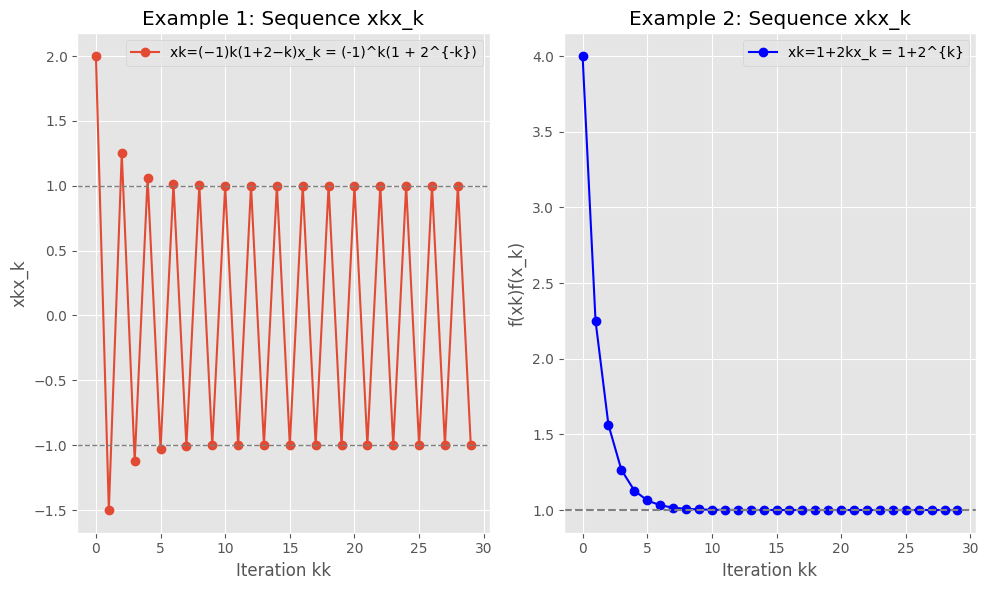

In [49]:
# 定义函数 f(x)=x^2
def f(x):
    return x**2
# 生成 k 的取值
k_vals = np.arange(0, 30)
# 示例 1：定义 x_k=(-1)^k*(1+2^{-k})
x_k = (-1)**k_vals * (1 + 2.0**(-k_vals))  # 使用 2.0 以避免 ValueError
# 示例 2：定义 x_k=1+2^{-k} 
x_k1 = 1 + 2.0**(-k_vals)  
# 计算 f(x_k)
f_k = f(x_k)
f_k1 = f(x_k1)
# 绘制 x_k
plt.subplot(1, 2, 1)
plt.plot(k_vals, x_k, 'o-', label='xk=(−1)k(1+2−k)x_k = (-1)^k(1 + 2^{-k})')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1)
plt.title('Example 1: Sequence xkx_k')
plt.xlabel('Iteration kk')
plt.ylabel('xkx_k')
plt.grid(True)
plt.legend()
# 绘制 f(x_k)
plt.subplot(1, 2, 2)
plt.plot(k_vals, f_k1, 'o-', color='blue', label='xk=1+2kx_k = 1+2^{k}')
plt.axhline(y=1, color='gray', linestyle='--')
plt.title('Example 2: Sequence xkx_k')
plt.xlabel('Iteration kk')
plt.ylabel('f(xk)f(x_k)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### 示例 1 分析（Analysis of Example 1）

**示例 1 的问题（Problem of Example 1）**：相对于步长长度（length of steps）而言，$f$ 值下降很小。可以通过要求下面条件来修正：

$$
\begin{aligned}
f(x^{(k)}+\lambda p) \leq{}& f(x^{(k)}) + \alpha\lambda\nabla f(x^{(k)})^\top p, \\
f(x^{(k+1)}) \leq{}& f(x^{(k)}) + \alpha\nabla f(x^{(k)})^\top(x^{(k+1)}-x^{(k)}),\quad \alpha\in(0,1).
\end{aligned}
$$

#### 示例 2 分析（Analysis of Example 2）

**示例 2 的问题（Problem of Example 2）**：相对于 $f$ 的初始下降速度（initial rate of decrease）而言，步长太小。可以通过要求下面条件来修正：

$$
\begin{aligned}
f(x^{(k)}+\lambda p) \geq{}& f(x^{(k)}) + \beta\lambda\nabla f(x^{(k)})^\top p, \\
f(x^{(k+1)}) \geq{}& f(x^{(k)}) + \beta\nabla f(x^{(k)})^\top(x^{(k+1)}-x^{(k)}),\quad \beta\in(0,1).
\end{aligned}
$$

## 参考文献（References）

* Eaton, Jonathan, Samuel Kortum, and Francis Kramarz. "An anatomy of international trade: Evidence from French firms." Econometrica 79.5 (2011): 1453-1498.
* Rust, John. "Optimal replacement of GMC bus engines: An empirical model of Harold Zurcher." Econometrica: Journal of the Econometric Society (1987): 999-1033.
* Richard W. Evans [Computational Methods for Economists using Python](https://opensourceecon.github.io/CompMethods/index.html) (Incomplete)
* Oden, J.T., Demkowicz, L.F. Applied Functional Analysis, 3rd Edition, 2018.
* Magnus, Jan R., and Heinz Neudecker. Matrix differential calculus with applications in statistics and econometrics. John Wiley & Sons, 2019.
* Thomas J. Sargent and John Stachurski, [Python Programming for Economics and Finance](https://python-programming.quantecon.org/intro.html)